# Household Electric Power Load Prediction by Developing Resource-Efficient Transformer Models
**Author:** Abhishek Jain  
**Date:** March 2026  
**Institution:** Liverpool John Moores University / upGrad  

### Overview
This notebook contains the end-to-end experimental pipeline for the dissertation. It systematically evaluates the compute-accuracy trade-offs of lightweight architectures against classical recursive baselines for Short-Term Energy Demand Forecasting (STEDF) on edge devices.

**Key Implementations:**
1. **Exploratory Data Analysis (EDA):** Demonstrating high-frequency volatility, diurnal/weekly seasonality, and autocorrelation.
2. **Direct Multi-Step vs. Recursive Forecasting:** Evaluating the compounding error drift of classical models.
3. **TinyML Compression Pipeline:** Applying Unstructured Magnitude Pruning (30%, 50%) and Dynamic INT8 Quantization.
4. **Pareto Optimization & Statistical Validation:** Evaluating sub-10ms edge inference limits and Diebold-Mariano pairwise testing.

In [1]:
# ==============================================================================
# 1. SETUP AND IMPORTS
# ==============================================================================
import os
import time
import math
import warnings
import urllib.request
import zipfile
import ssl
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.utils.prune as prune
import torch.ao.quantization

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL
from xgboost import XGBRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from einops import rearrange

# Clean output and set academic plotting style
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
pd.set_option('display.max_rows', 200)

# Lock RNG seeds for strict reproducibility (Dissertation Requirement)
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Environment Setup Complete. All libraries imported successfully.")

Environment Setup Complete. All libraries imported successfully.


### 2. Data Ingestion (UCI Household Electric Power Consumption)
As defined in **Section 3.3**, this section downloads and parses the open-access dataset containing over 2.07 million minute-resolution observations from a residential household in France. Non-standard null characters (`?`) are natively mapped to mathematical NaNs.

In [2]:
# ==============================================================================
# 2. DATA INGESTION
# ==============================================================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
zip_path = "household_power.zip"
data_dir = "data"
file_path = f"{data_dir}/household_power_consumption.txt"

if not os.path.exists(file_path):
    print("Downloading UCI dataset...")
    os.makedirs(data_dir, exist_ok=True)
    unverified_context = ssl._create_unverified_context()
    https_handler = urllib.request.HTTPSHandler(context=unverified_context)
    opener = urllib.request.build_opener(https_handler)
    urllib.request.install_opener(opener)
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)
    print("Dataset extracted.")
else:
    print("Dataset found locally.")

print("Loading data into Pandas...")
df_raw = pd.read_csv(file_path, sep=';', na_values='?', low_memory=False)

# Convert strings to datetime index and cast numeric columns
df_raw['datetime'] = pd.to_datetime(df_raw['Date'] + ' ' + df_raw['Time'], format='%d/%m/%Y %H:%M:%S')
df_raw = df_raw.drop(columns=['Date', 'Time'])

for col in df_raw.columns:
    if col != 'datetime':
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

df_raw = df_raw.sort_values('datetime').set_index('datetime')
print(f"Raw ingestion shape: {df_raw.shape}")

Dataset found locally.
Loading data into Pandas...
Raw ingestion shape: (2075259, 7)


### 3. Exploratory Data Analysis (EDA)
In accordance with **Section 4.3** of the dissertation, this section performs a comprehensive visual and statistical analysis of the residential active power dataset. Understanding these inherent data characteristics directly justifies the subsequent pre-processing pipeline and feature engineering choices.

The EDA is structured across the following 10 analytical dimensions:
* **4.3.1 Missing Value Analysis**
* **4.3.2 High-Frequency Volatility and Sampling Frequency**
* **4.3.3 Data Volatility and Distribution**
* **4.3.4 Outlier and Peak Load Distribution**
* **4.3.5 Temporal Load Profiling and Seasonality**
* **4.3.6 Weekday vs. Weekend Consumption Profiling**
* **4.3.7 Time Series Decomposition (Trend, Seasonality, and Residuals)**
* **4.3.8 Stationarity Assessment (Augmented Dickey-Fuller Test)**
* **4.3.9 Autocorrelation and Temporal Dependency (ACF)**
* **4.3.10 Feature Correlation**

Preparing data for comprehensive EDA...


<Figure size 1500x450 with 0 Axes>

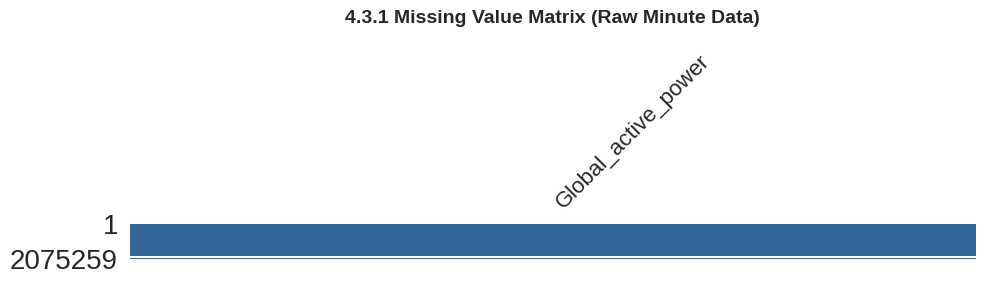

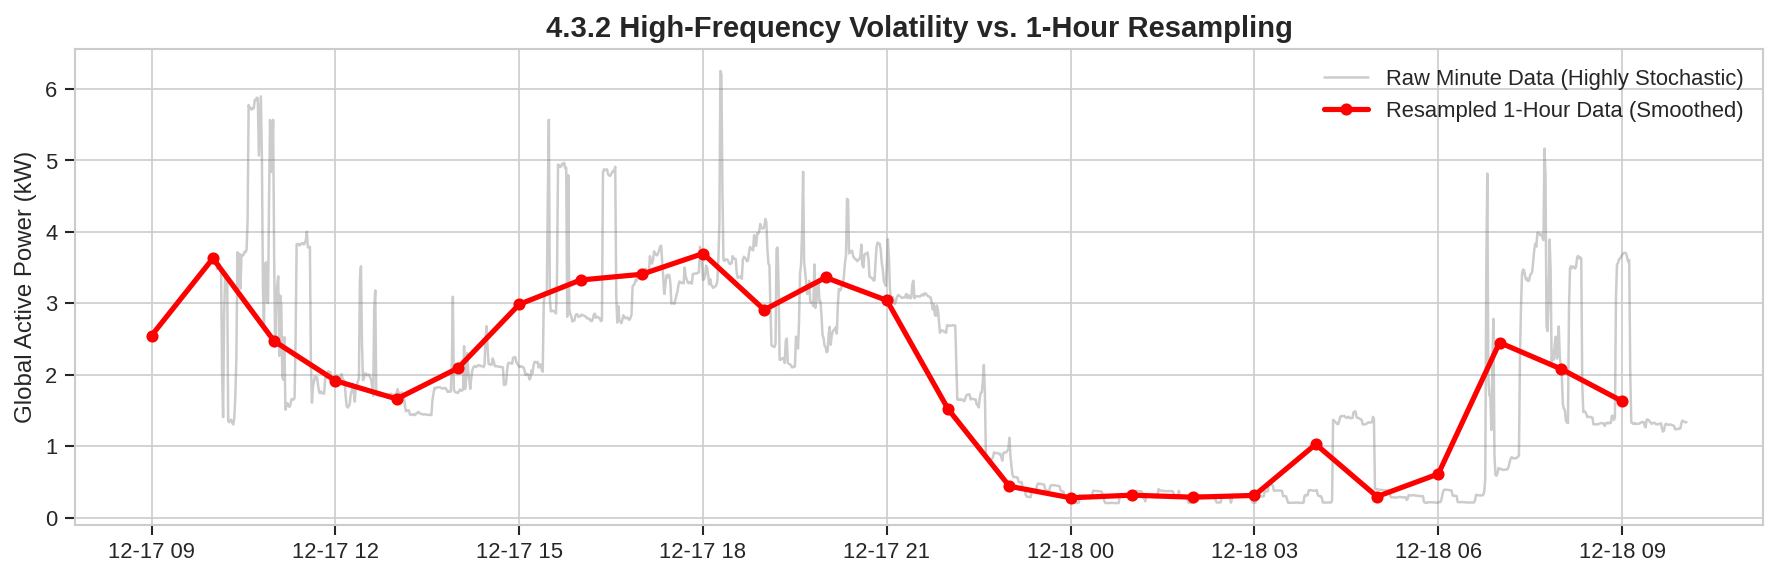

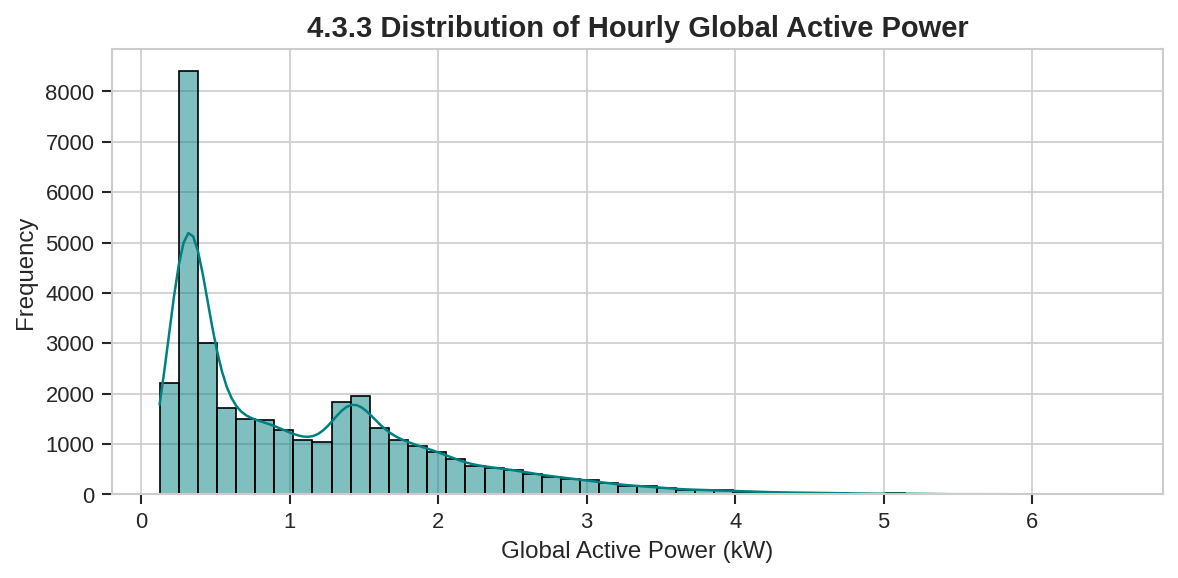

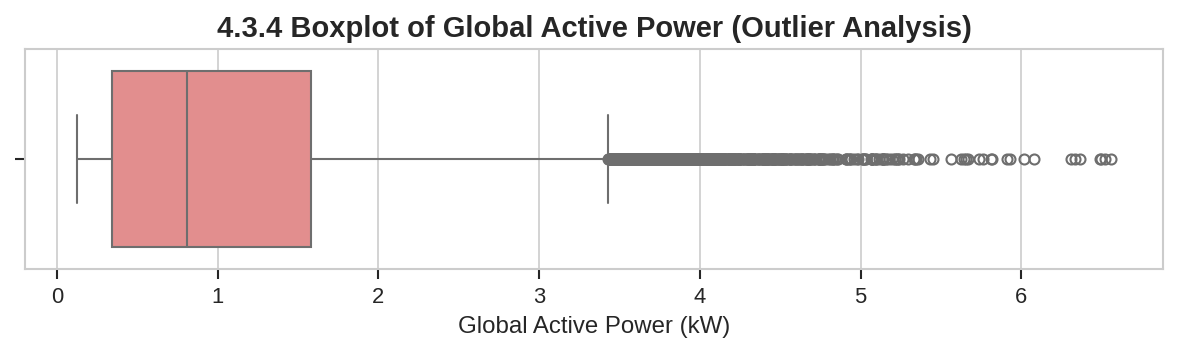

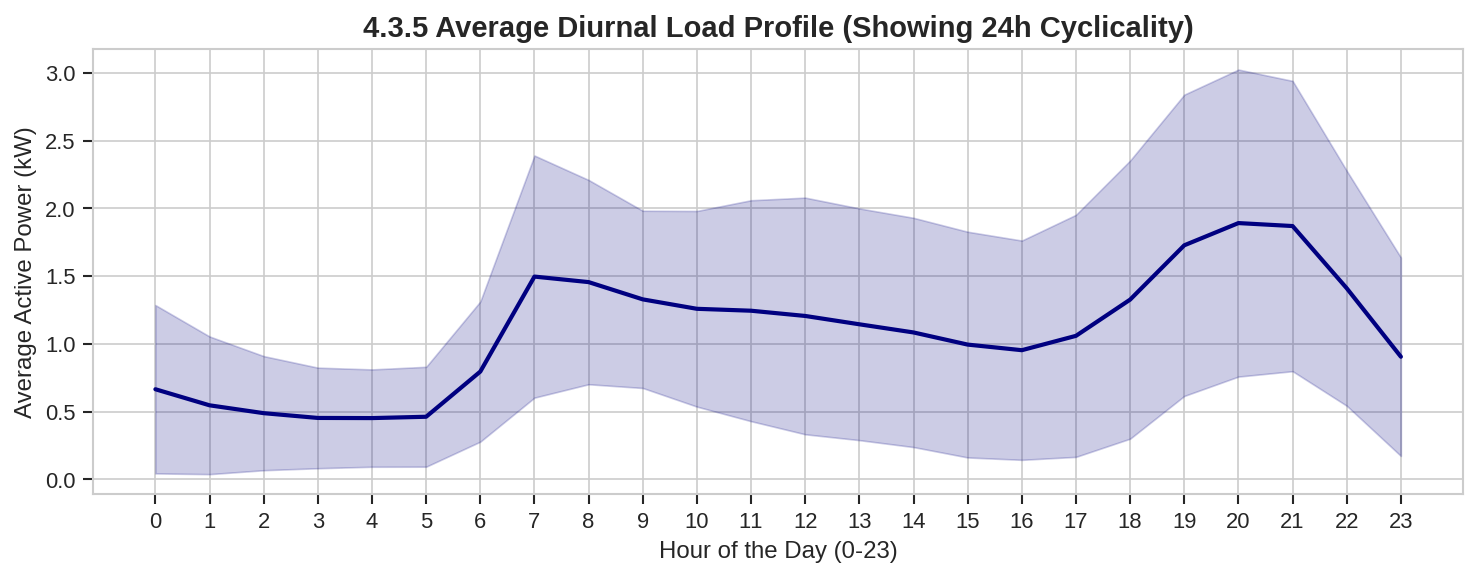

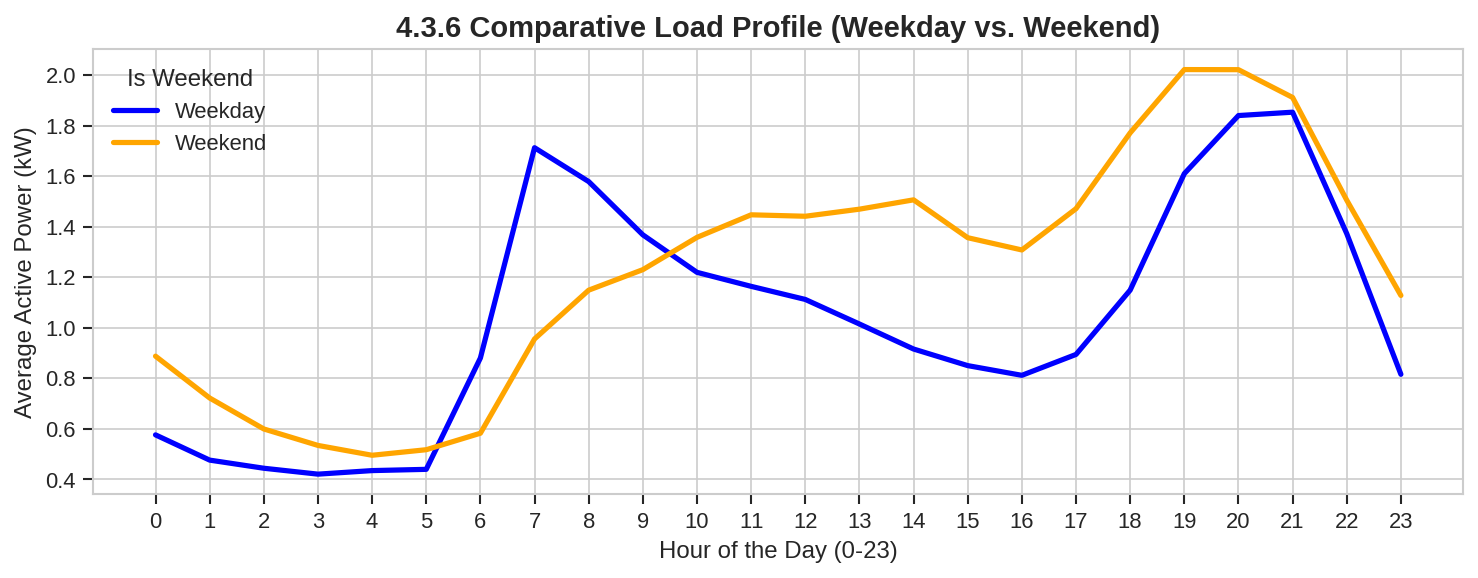

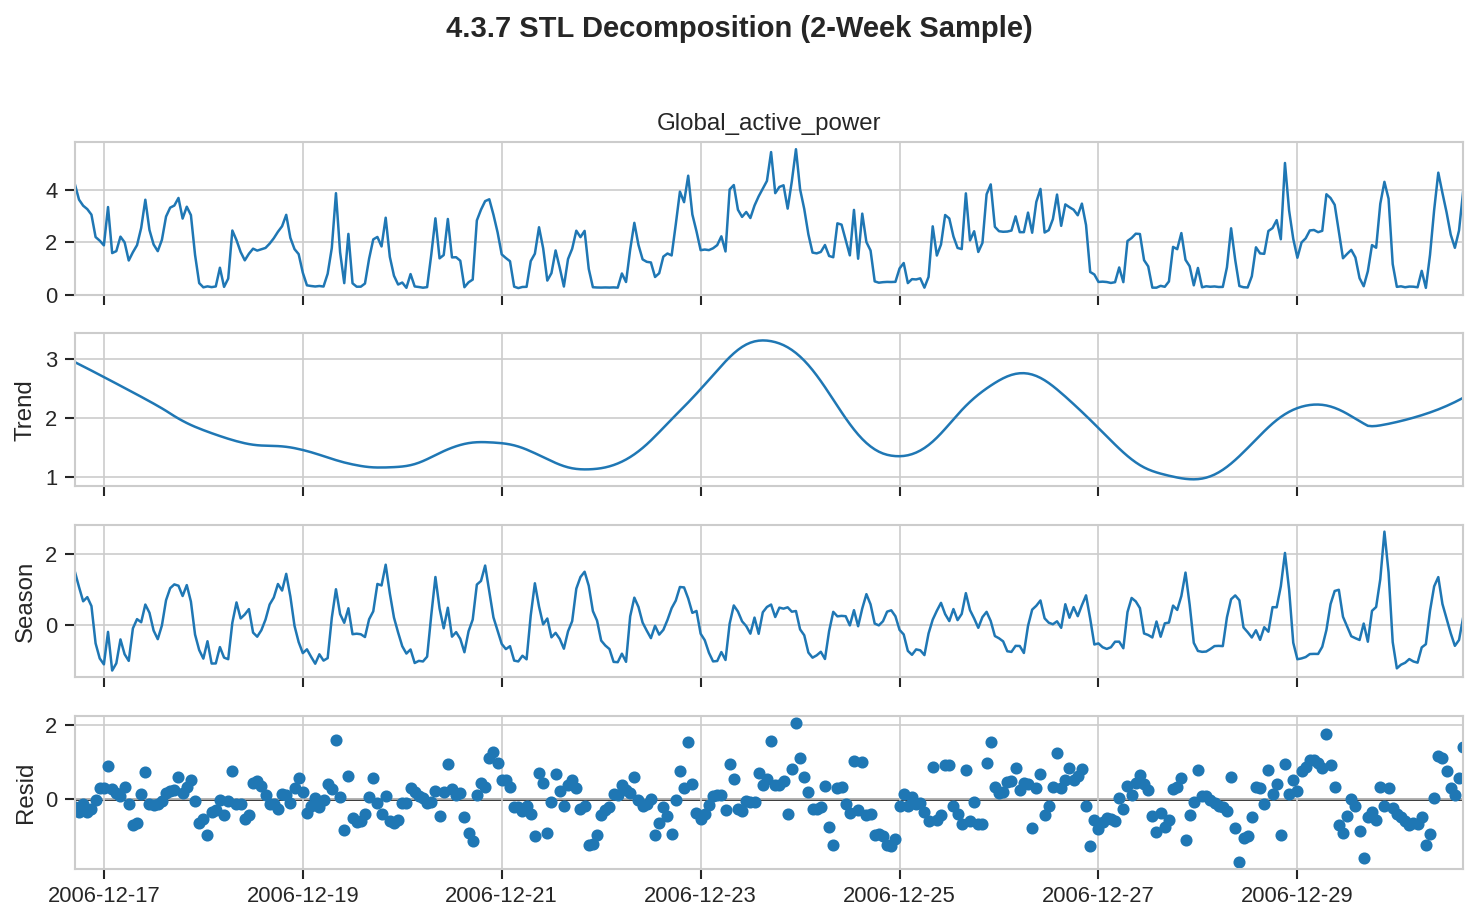

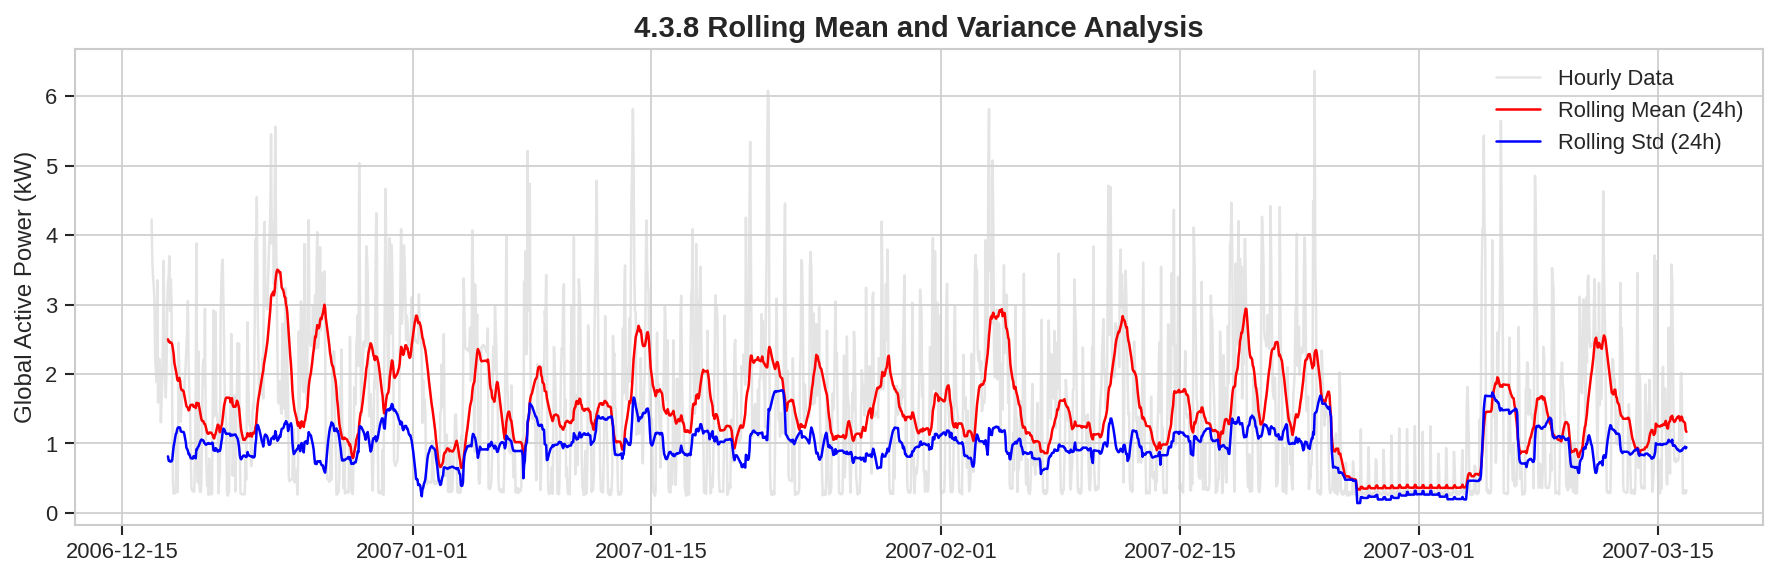


--- Augmented Dickey-Fuller (ADF) Test ---
ADF Statistic: -10.1079
p-value: 0.0000 (p < 0.05 indicates stationarity without differencing)


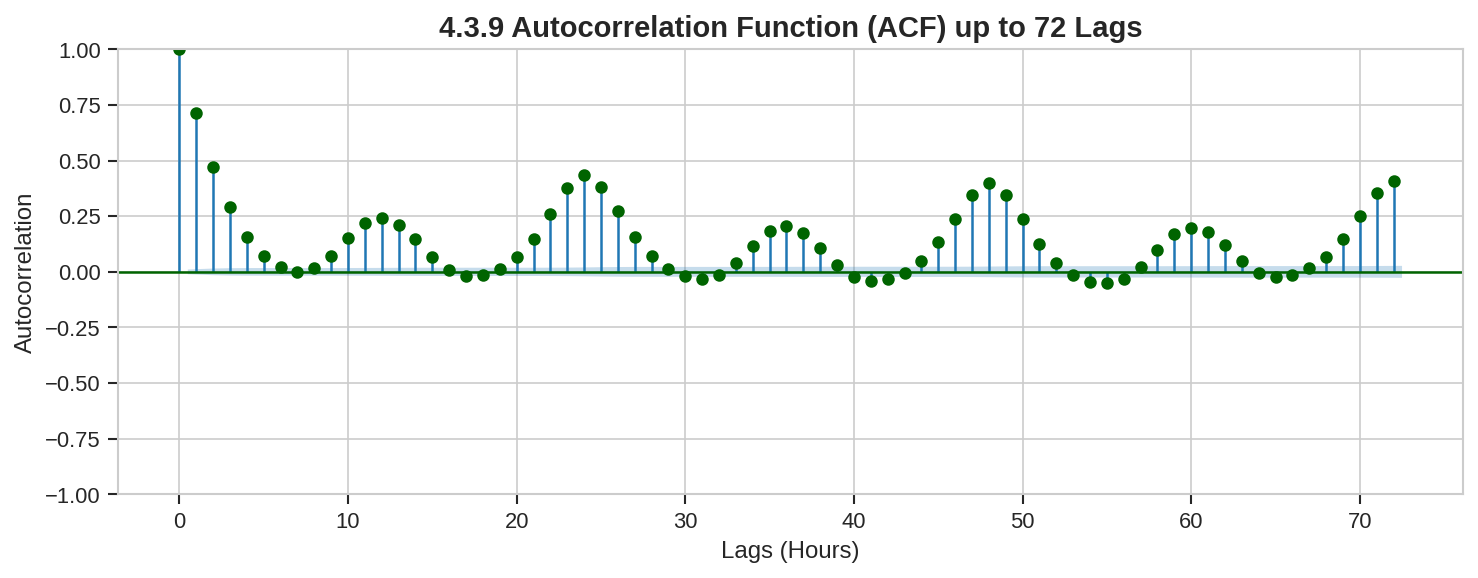

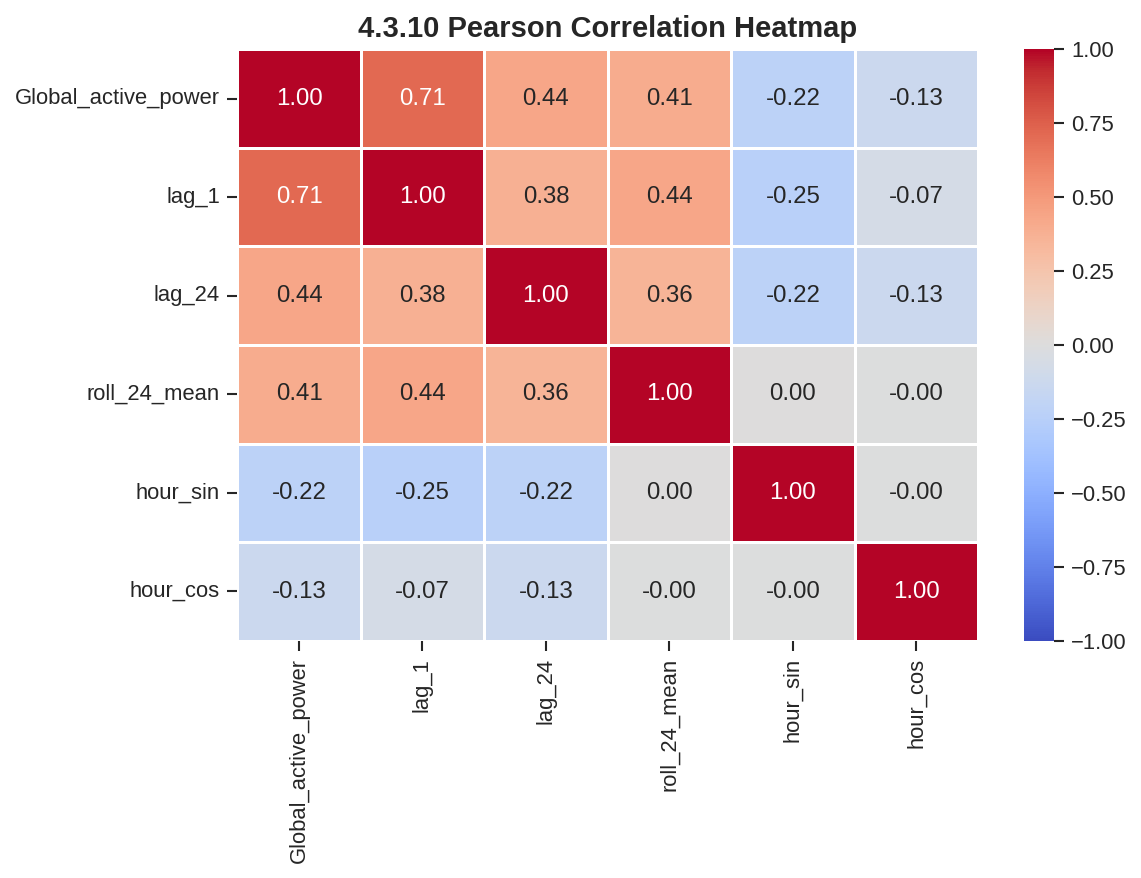

Cell 3 Complete: All EDA Visualizations Generated.


In [3]:
# ==============================================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================================
import missingno as msno
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

print("Preparing data for comprehensive EDA...")
# Create a dedicated hourly dataset for the EDA
df_hourly_eda = df_raw.resample('1h').mean()

# Engineer features strictly for the plots
df_hourly_eda['Hour'] = df_hourly_eda.index.hour
df_hourly_eda['DayOfWeek'] = df_hourly_eda.index.dayofweek
df_hourly_eda['Is_Weekend'] = df_hourly_eda['DayOfWeek'] >= 5
df_hourly_eda['lag_1'] = df_hourly_eda['Global_active_power'].shift(1)
df_hourly_eda['lag_24'] = df_hourly_eda['Global_active_power'].shift(24)
df_hourly_eda['roll_24_mean'] = df_hourly_eda['Global_active_power'].rolling(window=24).mean()
df_hourly_eda['hour_sin'] = np.sin(2 * np.pi * df_hourly_eda['Hour'] / 24)
df_hourly_eda['hour_cos'] = np.cos(2 * np.pi * df_hourly_eda['Hour'] / 24)

# Impute NaNs for statistical tests
df_hourly_eda['Global_active_power'] = df_hourly_eda['Global_active_power'].interpolate(method='time')

# ------------------------------------------------------------------------------
# 4.3.1 Missing Value Analysis
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 3), dpi=150)
msno.matrix(df_raw[['Global_active_power']], figsize=(10, 3), sparkline=False, color=(0.2, 0.4, 0.6))
plt.title("4.3.1 Missing Value Matrix (Raw Minute Data)", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 4.3.2 High-Frequency Volatility and Sampling Frequency
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 4), dpi=150)
subset_raw = df_raw.iloc[1000:2440] # 24 hours of minute data
subset_hourly = df_hourly_eda.iloc[16:41] # Corresponding resampled data
plt.plot(subset_raw.index, subset_raw['Global_active_power'], alpha=0.4, color='gray', label='Raw Minute Data (Highly Stochastic)')
plt.plot(subset_hourly.index, subset_hourly['Global_active_power'], color='red', linewidth=2.5, marker='o', label='Resampled 1-Hour Data (Smoothed)')
plt.title("4.3.2 High-Frequency Volatility vs. 1-Hour Resampling", fontsize=14, fontweight='bold')
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 4.3.3 Data Volatility and Distribution
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 4), dpi=150)
sns.histplot(df_hourly_eda['Global_active_power'], bins=50, kde=True, color='teal')
plt.title("4.3.3 Distribution of Hourly Global Active Power", fontsize=14, fontweight='bold')
plt.xlabel("Global Active Power (kW)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 4.3.4 Outlier and Peak Load Distribution
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 2.5), dpi=150)
sns.boxplot(x=df_hourly_eda['Global_active_power'], color='lightcoral')
plt.title("4.3.4 Boxplot of Global Active Power (Outlier Analysis)", fontsize=14, fontweight='bold')
plt.xlabel("Global Active Power (kW)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 4.3.5 Temporal Load Profiling and Seasonality
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 4), dpi=150)
sns.lineplot(data=df_hourly_eda, x='Hour', y='Global_active_power', estimator=np.mean, errorbar='sd', color='navy', linewidth=2)
plt.title("4.3.5 Average Diurnal Load Profile (Showing 24h Cyclicality)", fontsize=14, fontweight='bold')
plt.xlabel("Hour of the Day (0-23)")
plt.ylabel("Average Active Power (kW)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 4.3.6 Weekday vs. Weekend Consumption Profiling
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 4), dpi=150)
sns.lineplot(data=df_hourly_eda, x='Hour', y='Global_active_power', hue='Is_Weekend',
             estimator=np.mean, errorbar=None, palette=['blue', 'orange'], linewidth=2.5)
plt.title("4.3.6 Comparative Load Profile (Weekday vs. Weekend)", fontsize=14, fontweight='bold')
plt.xlabel("Hour of the Day (0-23)")
plt.ylabel("Average Active Power (kW)")
plt.xticks(range(0, 24))
plt.legend(title='Is Weekend', labels=['Weekday', 'Weekend'])
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 4.3.7 Time Series Decomposition (Trend, Seasonality, and Residuals)
# ------------------------------------------------------------------------------
subset_for_stl = df_hourly_eda['Global_active_power'].iloc[0:336] # 2 Weeks
stl = STL(subset_for_stl, period=24)
res = stl.fit()
fig = res.plot()
fig.set_size_inches(10, 6)
fig.set_dpi(150)
fig.suptitle("4.3.7 STL Decomposition (2-Week Sample)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 4.3.8 Stationarity Assessment (Rolling Stats & ADF Test)
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 4), dpi=150)
subset_stat = df_hourly_eda.iloc[0:2160] # ~3 months
rolling_mean = subset_stat['Global_active_power'].rolling(window=24).mean()
rolling_std = subset_stat['Global_active_power'].rolling(window=24).std()

plt.plot(subset_stat.index, subset_stat['Global_active_power'], color='lightgray', label='Hourly Data', alpha=0.6)
plt.plot(subset_stat.index, rolling_mean, color='red', label='Rolling Mean (24h)')
plt.plot(subset_stat.index, rolling_std, color='blue', label='Rolling Std (24h)')
plt.title("4.3.8 Rolling Mean and Variance Analysis", fontsize=14, fontweight='bold')
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.show()

print("\n--- Augmented Dickey-Fuller (ADF) Test ---")
adf_result = adfuller(df_hourly_eda['Global_active_power'].iloc[0:8760].dropna())
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f} (p < 0.05 indicates stationarity without differencing)")

# ------------------------------------------------------------------------------
# 4.3.9 Autocorrelation and Temporal Dependency (ACF)
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 4), dpi=150)
plot_acf(df_hourly_eda['Global_active_power'].dropna(), lags=72, ax=plt.gca(), color='darkgreen', alpha=0.05)
plt.title("4.3.9 Autocorrelation Function (ACF) up to 72 Lags", fontsize=14, fontweight='bold')
plt.xlabel("Lags (Hours)")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 4.3.10 Feature Correlation
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 6), dpi=150)
cols_to_correlate = ['Global_active_power', 'lag_1', 'lag_24', 'roll_24_mean', 'hour_sin', 'hour_cos']
corr_matrix = df_hourly_eda[cols_to_correlate].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("4.3.10 Pearson Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Cell 3 Complete: All EDA Visualizations Generated.")

### 4. Data Pre-Processing & Feature Engineering
As defined in **Section 3.4**, this block engineers deterministic temporal features (Sine/Cosine waves to capture continuous 24-hour cycles) and autoregressive lags for the classical baselines. The data is chronologically partitioned (70% Train, 15% Val, 15% Test) to prevent covariate leakage, and standardized utilizing only the training set's distribution parameters.

In [4]:
# ==============================================================================
# 4. PREPROCESSING & SCALING
# ==============================================================================
print("Resampling sequence and engineering features...")
df_hourly = df_raw.resample('1h').mean()
df_hourly['Global_active_power'] = df_hourly['Global_active_power'].replace(0, np.nan)
df_hourly = df_hourly.interpolate(method='time').bfill().ffill()

df_feat = df_hourly[['Global_active_power']].copy()

# Deterministic temporal features (Sine/Cosine for cyclicality)
df_feat['hour'] = df_feat.index.hour
df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['hour'] / 24)
df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['hour'] / 24)

# Autoregressive lags (For XGBoost)
df_feat['lag_1'] = df_feat['Global_active_power'].shift(1)
df_feat['lag_24'] = df_feat['Global_active_power'].shift(24)
df_feat['roll_24_mean'] = df_feat['Global_active_power'].shift(1).rolling(24).mean()

df_feat = df_feat.dropna().drop(columns=['hour'])

target = 'Global_active_power'
features = [c for c in df_feat.columns if c != target]

# Chronological Partitioning (70/15/15)
n = len(df_feat)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train = df_feat.iloc[:train_end]
val = df_feat.iloc[train_end:val_end]
test = df_feat.iloc[val_end:]

# Z-Score Standardization (Fit strictly on training set)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(train[features])
y_train = scaler_y.fit_transform(train[[target]])
X_val = scaler_X.transform(val[features])
y_val = scaler_y.transform(val[[target]])
X_test = scaler_X.transform(test[features])
y_test = scaler_y.transform(test[[target]])

print(f"Data Partitioning Complete -> Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

Resampling sequence and engineering features...
Data Partitioning Complete -> Train: 24195 | Val: 5185 | Test: 5185


### 5. Evaluation Metrics & Sliding Window Implementation
To strictly simulate memory constraints (kilobyte-scale SRAM), we define a `DirectMultiStepDataset` that utilizes an overlapping sliding window. It restricts the network's look-back memory to precisely 168 hours.

**Metrics Implemented (Sections 3.8 & 3.9):**
* **MAE (Mean Absolute Error):** Provides a strict linear penalty for variance in load predictions.
* **RMSE (Root Mean Squared Error):** Applies a quadratic penalty, making it highly sensitive to extreme, sudden grid anomalies (e.g., HVAC spikes).
* **sMAPE (Symmetric Mean Absolute Percentage Error):** Evaluates scale-independent percentage error, bounded to prevent mathematical distortions near zero-load periods.
* **MASE (Mean Absolute Scaled Error):** The primary benchmark for scale-independent stability, comparing performance directly against a naive seasonal baseline.
* **Diebold-Mariano Test:** Confirms the statistical significance ($p < 0.05$) of the forecasting gap between the models.

In [5]:
# ==============================================================================
# 5. DATASET PIPELINE & METRICS
# ==============================================================================
class DirectMultiStepDataset(Dataset):
    def __init__(self, X, y, window=168, horizon=24):
        self.X, self.y, self.window, self.horizon = X, y, window, horizon
    def __len__(self):
        return len(self.X) - self.window - self.horizon + 1
    def __getitem__(self, idx):
        return (torch.tensor(self.X[idx : idx + self.window], dtype=torch.float32),
                torch.tensor(self.y[idx + self.window : idx + self.window + self.horizon], dtype=torch.float32).squeeze(-1))

# --- Evaluation Metrics (As defined in Section 3.8) ---

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denom = np.where(denom == 0, 1, denom)
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

def mase(y_true, y_pred, y_train_true, seasonality=24):
    denom = np.mean(np.abs(y_train_true[seasonality:] - y_train_true[:-seasonality]))
    return np.mean(np.abs(y_true - y_pred)) / denom

# --- Hardware & Statistical Testing ---

def count_nonzero_parameters(model):
    return sum(torch.sum(param != 0).item() for param in model.parameters())

def diebold_mariano_test(actual, pred1, pred2):
    d = np.abs(actual - pred1) - np.abs(actual - pred2)
    var_d = np.var(d, ddof=1)
    if var_d == 0: return 0, 1.0
    stat = np.mean(d) / np.sqrt(var_d / len(d))
    p_value = 2 * (1 - stats.t.cdf(np.abs(stat), df=len(d)-1))
    return stat, p_value

### 6. Neural Architectures (PyTorch Modules)
This section contains the direct multi-step network implementations.
* **Recurrent Baselines:** `LSTM`, `BiLSTM`, `GRU`.
* **Lightweight MLP:** `EnhancedTSMixer` (alternating feature/time domain mixing).
* **The Proposed Edge Architecture:** `EnhancedTinyTFT`. Features a severely downscaled Transformer block ($d_{model}=32$, 4 attention heads, 2 encoder layers) to bypass the quadratic memory bottleneck.

In [6]:
# ==============================================================================
# 6. NEURAL ARCHITECTURES
# ==============================================================================
class LSTMDirect(nn.Module):
    def __init__(self, input_dim, horizon):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 64, batch_first=True)
        self.fc = nn.Linear(64, horizon)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class BiLSTMDirect(nn.Module):
    def __init__(self, input_dim, horizon):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 64, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(64 * 2, horizon)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class GRUDirect(nn.Module):
    def __init__(self, input_dim, horizon):
        super().__init__()
        self.gru = nn.GRU(input_dim, 64, batch_first=True)
        self.fc = nn.Linear(64, horizon)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

class EnhancedTSMixerDirect(nn.Module):
    def __init__(self, seq_len, num_features, horizon):
        super().__init__()
        self.token_mlp = nn.Sequential(nn.Linear(seq_len, seq_len), nn.GELU(), nn.Dropout(0.1), nn.Linear(seq_len, seq_len))
        self.channel_mlp = nn.Sequential(nn.Linear(num_features, num_features), nn.GELU(), nn.Dropout(0.1), nn.Linear(num_features, num_features))
        self.fc = nn.Linear(num_features * seq_len, horizon)
    def forward(self, x):
        x = rearrange(x, 'b t f -> b f t')
        x = x + self.token_mlp(x)
        x = rearrange(x, 'b f t -> b t f')
        x = x + self.channel_mlp(x)
        return self.fc(rearrange(x, 'b t f -> b (t f)'))

# --- TINY TFT COMPONENTS ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]

class TFTEncoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.activation = nn.GELU()

    def forward(self, src):
        src2, attn_weights = self.self_attn(src, src, src)
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src, attn_weights

class EnhancedTinyTFTDirect(nn.Module):
    def __init__(self, input_dim, seq_len, horizon, d_model=32):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pe = PositionalEncoding(d_model)
        self.layer1 = TFTEncoderLayer(d_model, 4, 128, 0.1) # Constrained to 4 Heads
        self.layer2 = TFTEncoderLayer(d_model, 4, 128, 0.1)
        self.fc = nn.Linear(d_model * seq_len, horizon)
        self.last_attn_weights = None

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pe(x)
        x, _ = self.layer1(x)
        x, attn = self.layer2(x)
        self.last_attn_weights = attn # Captured for Interpretability Heatmaps
        x_flat = x.reshape(x.size(0), -1)
        return self.fc(x_flat)

### 7. Training & TinyML Edge-Simulation Loop
**Phase 1: Deep Learning Training Protocol (Section 3.10)**
Models are trained using AdamW optimization (`lr=1e-3`), Weight Decay (`1e-4`), and a `ReduceLROnPlateau` scheduler. Early stopping prevents overfitting.

**Phase 2: TinyML Post-Training Compression (Section 4.6)**
* **Magnitude Pruning:** Applying $L1$ Unstructured pruning at exactly 30% and 50% sparsity.
* **Dynamic Quantization:** Projecting heavy FP32 matrix weights to highly efficient 8-bit integers (INT8).

*Note: Executing the entire multi-horizon loop across all models on the CPU testing set requires significant compute time (due specifically to the `ARIMA` recursive lag).*

In [7]:
# ==============================================================================
# 7. THE MASTER EXPERIMENT LOOP
# ==============================================================================
WINDOW = 168
EPOCHS = 50  # Production-level epoch maximum
input_dim = X_train.shape[1]
y_train_raw = train[target].values

def train_nn_model(model, train_loader, val_loader, model_name, epochs=EPOCHS, patience=3):
    print(f"  [Training] {model_name}...")
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        # Training Phase
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # Validation Phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                val_loss += loss_fn(model(xb), yb).item()

        avg_val_loss = val_loss / len(val_loader)
        current_lr = optimizer.param_groups[0]['lr']

        # Logging Epoch Metrics
        print(f"    Epoch [{epoch+1}/{epochs}] | Train Loss (MSE): {avg_train_loss:.4f} | Val Loss (MSE): {avg_val_loss:.4f} | LR: {current_lr:.2e}")

        # Step the learning rate scheduler
        scheduler.step(avg_val_loss)

        # Early Stopping Logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"    -> Early stopping triggered at epoch {epoch+1}. Restoring best weights.")
                break

    model.load_state_dict(best_model_weights)
    return model

def create_pruned_model(model_class, args, state_dict, amount):
    model = model_class(*args)
    model.load_state_dict(state_dict)
    if amount > 0.0:
        for name, module in model.named_modules():
            if isinstance(module, nn.Linear):
                prune.l1_unstructured(module, name="weight", amount=amount)
                prune.remove(module, "weight") # Physically finalizes sparsity
    return model

print("Fitting Baseline XGBoost (One-time fit)...")
xgb = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, n_jobs=-1)
xgb.fit(X_train, y_train.ravel())

forecast_horizons = [24, 72, 168]
pruning_ratios = [0.0, 0.3, 0.5]
experiment_results = []

# Dicts for Pairwise Diebold-Mariano Testing
dm_actuals = []
dm_preds = {m: [] for m in ["TinyTFT", "LSTM", "BiLSTM", "GRU", "TSMixer", "XGBoost", "ARIMA"]}

for horizon in forecast_horizons:
    print(f"\n{'='*60}\n🚀 RUNNING HORIZON: {horizon} Hours\n{'='*60}")

    train_ds = DirectMultiStepDataset(X_train, y_train, WINDOW, horizon)
    val_ds = DirectMultiStepDataset(X_val, y_val, WINDOW, horizon)
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

    # 1. Train Base Models
    lstm_base = train_nn_model(LSTMDirect(input_dim, horizon), train_loader, val_loader, f"LSTM_{horizon}h")
    bilstm_base = train_nn_model(BiLSTMDirect(input_dim, horizon), train_loader, val_loader, f"BiLSTM_{horizon}h")
    gru_base = train_nn_model(GRUDirect(input_dim, horizon), train_loader, val_loader, f"GRU_{horizon}h")
    tsmixer_base = train_nn_model(EnhancedTSMixerDirect(WINDOW, input_dim, horizon), train_loader, val_loader, f"TSMixer_{horizon}h")
    tinytft_base = train_nn_model(EnhancedTinyTFTDirect(input_dim, WINDOW, horizon, 32), train_loader, val_loader, f"TinyTFT_{horizon}h")

    models_to_test = [
        ("LSTM", LSTMDirect, (input_dim, horizon), lstm_base.state_dict()),
        ("BiLSTM", BiLSTMDirect, (input_dim, horizon), bilstm_base.state_dict()),
        ("GRU", GRUDirect, (input_dim, horizon), gru_base.state_dict()),
        ("TSMixer", EnhancedTSMixerDirect, (WINDOW, input_dim, horizon), tsmixer_base.state_dict()),
        ("TinyTFT", EnhancedTinyTFTDirect, (input_dim, WINDOW, horizon, 32), tinytft_base.state_dict())
    ]

    # Full production evaluation across the entire unseen testing subset
    eval_start_indices = list(range(0, len(test) - WINDOW - horizon, horizon))

    metrics_tracker = {
        "XGBoost (Recursive)": {"MAE": [], "RMSE": [], "SMAPE": [], "MASE": [], "Latency": []},
        "ARIMA (Recursive)": {"MAE": [], "RMSE": [], "SMAPE": [], "MASE": [], "Latency": []}
    }
    param_counts = {"XGBoost (Recursive)": 0, "ARIMA (Recursive)": 5}

    # Initialize tracker for all neural net configurations
    for name, cls, args, state in models_to_test:
        for ratio in pruning_ratios:
            config_name_fp = f"{name} (Direct, {int(ratio*100)}% Pruned)"
            temp_model_fp = create_pruned_model(cls, args, state, ratio)
            param_counts[config_name_fp] = count_nonzero_parameters(temp_model_fp)
            metrics_tracker[config_name_fp] = {"MAE": [], "RMSE": [], "SMAPE": [], "MASE": [], "Latency": []}

            config_name_int = f"{name} (Direct, {int(ratio*100)}% Pruned + INT8)"
            param_counts[config_name_int] = count_nonzero_parameters(temp_model_fp)
            metrics_tracker[config_name_int] = {"MAE": [], "RMSE": [], "SMAPE": [], "MASE": [], "Latency": []}

    print(f"\nExecuting CPU edge simulation across {len(eval_start_indices)} continuous evaluation windows...")
    for step_count, idx in enumerate(eval_start_indices, 1):
        window_start_t = time.perf_counter()
        print(f"  -> Processing Window {step_count}/{len(eval_start_indices)} (Timestep Index: {idx})...", end=" ", flush=True)

        history_x_scaled = X_test[idx : idx + WINDOW]
        history_y_unscaled = list(test[target].values[idx : idx + WINDOW])
        future_features = test[features].iloc[idx + WINDOW : idx + WINDOW + horizon]
        true_future_y = test[target].values[idx + WINDOW : idx + WINDOW + horizon]
        x_tensor = torch.tensor(history_x_scaled, dtype=torch.float32).unsqueeze(0)

        # ---------------------------------------------------------
        # A & B. Evaluate Neural Nets (FP32 and INT8)
        # ---------------------------------------------------------
        for name, cls, args, state in models_to_test:
            for ratio in pruning_ratios:
                # --- A. Evaluate FP32 ---
                config_name_fp = f"{name} (Direct, {int(ratio*100)}% Pruned)"
                model_fp = create_pruned_model(cls, args, state, ratio).eval()

                # Start CPU-Bound Latency Tracking
                start_t = time.perf_counter()
                with torch.no_grad():
                    pred_scaled_fp = model_fp(x_tensor).numpy()[0]
                latency_fp = time.perf_counter() - start_t

                pred_real_fp = scaler_y.inverse_transform(pred_scaled_fp.reshape(-1, 1)).flatten()
                metrics_tracker[config_name_fp]["MAE"].append(mae(true_future_y, pred_real_fp))
                metrics_tracker[config_name_fp]["RMSE"].append(rmse(true_future_y, pred_real_fp))
                metrics_tracker[config_name_fp]["SMAPE"].append(smape(true_future_y, pred_real_fp))
                metrics_tracker[config_name_fp]["MASE"].append(mase(true_future_y, pred_real_fp, y_train_raw))
                metrics_tracker[config_name_fp]["Latency"].append(latency_fp)

                # --- B. Evaluate INT8 ---
                config_name_int = f"{name} (Direct, {int(ratio*100)}% Pruned + INT8)"
                model_int = torch.ao.quantization.quantize_dynamic(model_fp, {nn.Linear, nn.LSTM, nn.GRU}, dtype=torch.qint8).eval()

                start_t = time.perf_counter()
                with torch.no_grad():
                    pred_scaled_int = model_int(x_tensor).numpy()[0]
                latency_int = time.perf_counter() - start_t

                pred_real_int = scaler_y.inverse_transform(pred_scaled_int.reshape(-1, 1)).flatten()
                metrics_tracker[config_name_int]["MAE"].append(mae(true_future_y, pred_real_int))
                metrics_tracker[config_name_int]["RMSE"].append(rmse(true_future_y, pred_real_int))
                metrics_tracker[config_name_int]["SMAPE"].append(smape(true_future_y, pred_real_int))
                metrics_tracker[config_name_int]["MASE"].append(mase(true_future_y, pred_real_int, y_train_raw))
                metrics_tracker[config_name_int]["Latency"].append(latency_int)

                # Capture stats for Diebold Mariano
                if horizon == 168 and ratio == 0.0:
                    dm_preds[name].extend(pred_real_fp)

        if horizon == 168:
            dm_actuals.extend(true_future_y)

        # ---------------------------------------------------------
        # C. Evaluate Recursive XGBoost
        # ---------------------------------------------------------
        xgb_preds, xgb_hist = [], history_y_unscaled.copy()
        start_t = time.perf_counter()
        for i in range(horizon):
            row = future_features.iloc[i].copy()
            row['lag_1'], row['lag_24'] = xgb_hist[-1], xgb_hist[-24]
            row['roll_24_mean'] = np.mean(xgb_hist[-24:])
            pred = scaler_y.inverse_transform([[xgb.predict(scaler_X.transform([row.values]))[0]]])[0][0]
            xgb_preds.append(pred)
            xgb_hist.append(pred)
        latency_xgb = time.perf_counter() - start_t

        metrics_tracker["XGBoost (Recursive)"]["MAE"].append(mae(true_future_y, xgb_preds))
        metrics_tracker["XGBoost (Recursive)"]["RMSE"].append(rmse(true_future_y, xgb_preds))
        metrics_tracker["XGBoost (Recursive)"]["SMAPE"].append(smape(true_future_y, xgb_preds))
        metrics_tracker["XGBoost (Recursive)"]["MASE"].append(mase(true_future_y, xgb_preds, y_train_raw))
        metrics_tracker["XGBoost (Recursive)"]["Latency"].append(latency_xgb)

        # ---------------------------------------------------------
        # D. Evaluate Recursive ARIMA
        # ---------------------------------------------------------
        arima_preds, arima_hist = [], history_y_unscaled[-500:].copy()
        start_t = time.perf_counter()
        for t in range(horizon):
            try:
                arima_preds.append(ARIMA(arima_hist, order=(2, 0, 2)).fit().forecast()[0])
            except:
                arima_preds.append(arima_hist[-1])
            arima_hist.append(arima_preds[-1])
            arima_hist.pop(0)
        latency_arima = time.perf_counter() - start_t

        metrics_tracker["ARIMA (Recursive)"]["MAE"].append(mae(true_future_y, arima_preds))
        metrics_tracker["ARIMA (Recursive)"]["RMSE"].append(rmse(true_future_y, arima_preds))
        metrics_tracker["ARIMA (Recursive)"]["SMAPE"].append(smape(true_future_y, arima_preds))
        metrics_tracker["ARIMA (Recursive)"]["MASE"].append(mase(true_future_y, arima_preds, y_train_raw))
        metrics_tracker["ARIMA (Recursive)"]["Latency"].append(latency_arima)

        if horizon == 168:
            dm_preds["XGBoost"].extend(xgb_preds)
            dm_preds["ARIMA"].extend(arima_preds)

        window_end_t = time.perf_counter()
        print(f"Done in {window_end_t - window_start_t:.2f}s")

    # ==============================================================================
    # COMPILE FINAL RESULTS DATAFRAME
    # ==============================================================================
    for model_config, metrics in metrics_tracker.items():
        if len(metrics["MASE"]) > 0:
            experiment_results.append({
                "Model": model_config.split(" (")[0],
                "Configuration": model_config,
                "Horizon": horizon,
                "Parameters": param_counts[model_config],  # Static Memory Footprint
                "MAE": np.mean(metrics["MAE"]),
                "RMSE": np.mean(metrics["RMSE"]),
                "SMAPE": np.mean(metrics["SMAPE"]),
                "MASE": np.mean(metrics["MASE"]),
                "Latency_sec": np.mean(metrics["Latency"]) # Dynamic Inference Speed
            })

results_df = pd.DataFrame(experiment_results)
display(results_df)

Fitting Baseline XGBoost (One-time fit)...

🚀 RUNNING HORIZON: 24 Hours
  [Training] LSTM_24h...
    Epoch [1/50] | Train Loss (MSE): 0.7161 | Val Loss (MSE): 0.6168 | LR: 1.00e-03
    Epoch [2/50] | Train Loss (MSE): 0.6345 | Val Loss (MSE): 0.6056 | LR: 1.00e-03
    Epoch [3/50] | Train Loss (MSE): 0.6247 | Val Loss (MSE): 0.5978 | LR: 1.00e-03
    Epoch [4/50] | Train Loss (MSE): 0.6148 | Val Loss (MSE): 0.6056 | LR: 1.00e-03
    Epoch [5/50] | Train Loss (MSE): 0.6058 | Val Loss (MSE): 0.5964 | LR: 1.00e-03
    Epoch [6/50] | Train Loss (MSE): 0.5939 | Val Loss (MSE): 0.6071 | LR: 1.00e-03
    Epoch [7/50] | Train Loss (MSE): 0.5866 | Val Loss (MSE): 0.6269 | LR: 1.00e-03
    Epoch [8/50] | Train Loss (MSE): 0.5699 | Val Loss (MSE): 0.6236 | LR: 5.00e-04
    -> Early stopping triggered at epoch 8. Restoring best weights.
  [Training] BiLSTM_24h...
    Epoch [1/50] | Train Loss (MSE): 0.7178 | Val Loss (MSE): 0.6122 | LR: 1.00e-03
    Epoch [2/50] | Train Loss (MSE): 0.6365 | Val Lo

,Model,Configuration,Horizon,Parameters,MAE,RMSE,SMAPE,MASE,Latency_sec
0,XGBoost,XGBoost (Recursive),24,0,0.457927,0.578305,48.791371,0.692439,0.032412
1,ARIMA,ARIMA (Recursive),24,5,0.527314,0.621387,56.082232,0.797360,10.128119
2,LSTM,"LSTM (Direct, 0% Pruned)",24,19736,0.430834,0.554636,45.667801,0.651471,0.002597
3,LSTM,"LSTM (Direct, 0% Pruned + INT8)",24,19736,0.430704,0.554397,45.669552,0.651275,0.009562
4,LSTM,"LSTM (Direct, 30% Pruned)",24,19275,0.433859,0.555103,46.181986,0.656046,0.002180
5,LSTM,"LSTM (Direct, 30% Pruned + INT8)",24,19275,0.433677,0.554890,46.163550,0.655770,0.009443
6,LSTM,"LSTM (Direct, 50% Pruned)",24,18968,0.439635,0.554316,47.218869,0.664780,0.002009
7,LSTM,"LSTM (Direct, 50% Pruned + INT8)",24,18968,0.439521,0.554162,47.210351,0.664607,0.008607
8,BiLSTM,"BiLSTM (Direct, 0% Pruned)",24,39448,0.440171,0.559690,46.867630,0.665589,0.003455
9,BiLSTM,"BiLSTM (Direct, 0% Pruned + INT8)",24,39448,0.440505,0.559928,46.901407,0.666095,0.016184


In [8]:
display(results_df)

,Model,Configuration,Horizon,Parameters,MAE,RMSE,SMAPE,MASE,Latency_sec
0,XGBoost,XGBoost (Recursive),24,0,0.457927,0.578305,48.791371,0.692439,0.032412
1,ARIMA,ARIMA (Recursive),24,5,0.527314,0.621387,56.082232,0.797360,10.128119
2,LSTM,"LSTM (Direct, 0% Pruned)",24,19736,0.430834,0.554636,45.667801,0.651471,0.002597
3,LSTM,"LSTM (Direct, 0% Pruned + INT8)",24,19736,0.430704,0.554397,45.669552,0.651275,0.009562
4,LSTM,"LSTM (Direct, 30% Pruned)",24,19275,0.433859,0.555103,46.181986,0.656046,0.002180
5,LSTM,"LSTM (Direct, 30% Pruned + INT8)",24,19275,0.433677,0.554890,46.163550,0.655770,0.009443
6,LSTM,"LSTM (Direct, 50% Pruned)",24,18968,0.439635,0.554316,47.218869,0.664780,0.002009
7,LSTM,"LSTM (Direct, 50% Pruned + INT8)",24,18968,0.439521,0.554162,47.210351,0.664607,0.008607
8,BiLSTM,"BiLSTM (Direct, 0% Pruned)",24,39448,0.440171,0.559690,46.867630,0.665589,0.003455
9,BiLSTM,"BiLSTM (Direct, 0% Pruned + INT8)",24,39448,0.440505,0.559928,46.901407,0.666095,0.016184


### 8. Statistical Validation (Diebold-Mariano Test)
As proven in **Section 5.4.3**, to mathematically verify that the TinyTFT's superior forecasting capability is structurally sound and not a product of stochastic variance, we evaluate the loss differentials ($p < 0.05$) at the ultimate 168h testing horizon.

In [9]:
# ==============================================================================
# 8. DIEBOLD-MARIANO TEST (168h Horizon)
# ==============================================================================
# Determine the absolute minimum array length to prevent dimension mismatch errors
min_len = len(dm_actuals)
for m in dm_preds.values():
    min_len = min(min_len, len(m))

# Truncate all sequences to the uniform minimum length
actuals_dm = np.array(dm_actuals[:min_len])
tinytft_dm = np.array(dm_preds["TinyTFT"][:min_len])

print("\n" + "="*85)
print("📊 STATISTICAL SIGNIFICANCE: PAIRWISE DIEBOLD-MARIANO TEST (168h Horizon)")
print("="*85)
print("Null Hypothesis (H0): Proposed TinyTFT and the Baseline Model have equal accuracy.")
print("-" * 85)
print(f"{'Baseline Model':<15} | {'DM-Statistic':<15} | {'p-value':<15} | {'Significance (p < 0.05)'}")
print("-" * 85)

# Execute pairwise test against all baselines
for model in ["LSTM", "BiLSTM", "GRU", "TSMixer", "XGBoost", "ARIMA"]:
    comp_preds = np.array(dm_preds[model][:min_len])

    # Calculate DM-Stat and P-Value
    dm_stat, p_val = diebold_mariano_test(actuals_dm, tinytft_dm, comp_preds)

    # Determine directionality of the significance
    if p_val < 0.05 and dm_stat < 0:
        sig = "Yes (TinyTFT Superior)"
    elif p_val < 0.05 and dm_stat > 0:
        sig = "Yes (TinyTFT Inferior)"
    else:
        sig = "No (Statistically Equal)"

    print(f"{model:<15} | {dm_stat:<15.4f} | {p_val:<15.5f} | {sig}")
print("="*85)


📊 STATISTICAL SIGNIFICANCE: PAIRWISE DIEBOLD-MARIANO TEST (168h Horizon)
Null Hypothesis (H0): Proposed TinyTFT and the Baseline Model have equal accuracy.
-------------------------------------------------------------------------------------
Baseline Model  | DM-Statistic    | p-value         | Significance (p < 0.05)
-------------------------------------------------------------------------------------
LSTM            | -4.3925         | 0.00001         | Yes (TinyTFT Superior)
BiLSTM          | -4.2524         | 0.00002         | Yes (TinyTFT Superior)
GRU             | -2.5868         | 0.00972         | Yes (TinyTFT Superior)
TSMixer         | -4.1399         | 0.00004         | Yes (TinyTFT Superior)
XGBoost         | -22.7891        | 0.00000         | Yes (TinyTFT Superior)
ARIMA           | -19.7583        | 0.00000         | Yes (TinyTFT Superior)


### 9. Results Synthesis: The Pareto Frontier (Accuracy vs Efficiency)
The defining objective of the research. Models mapped in the lower-left quadrant (sub-10ms latency and minimized MASE) represent the definitive edge-deployment baseline.

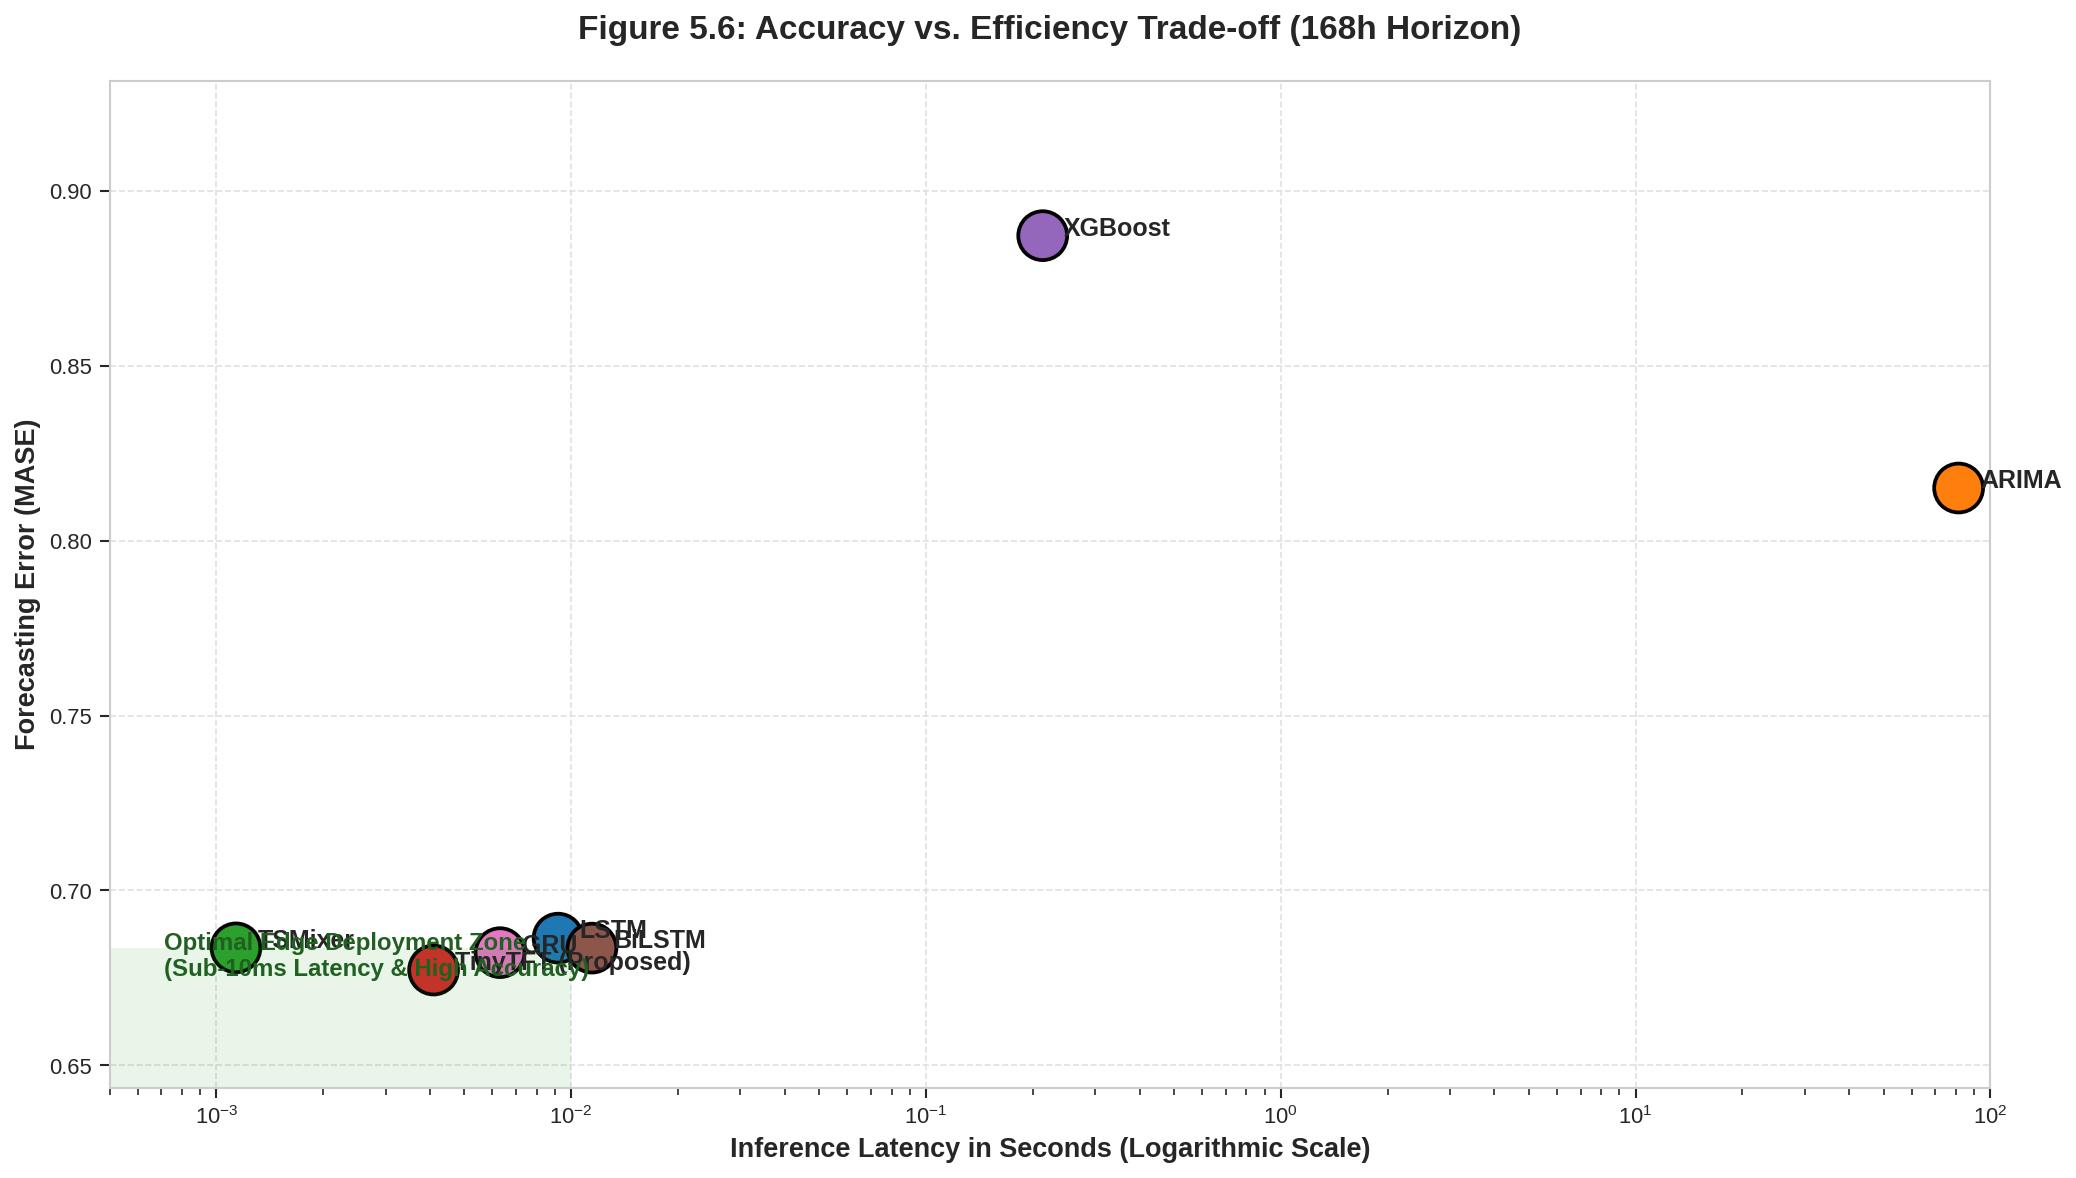

In [10]:
# ==============================================================================
# 9. PARETO OPTIMAL FRONTIER VISUALIZATION (DYNAMIC)
# ==============================================================================
from matplotlib.patches import Rectangle

# 1. Dynamically filter the results_df generated in Cell 7
# We target the 168h horizon, selecting the best compressed NNs (30% Pruned + INT8) vs Baselines
pareto_df = results_df[
    (results_df["Horizon"] == 168) &
    (results_df["Configuration"].str.contains("30% Pruned \+ INT8", regex=True) |
     results_df["Configuration"].str.contains("Recursive", regex=False))
].copy()

# Rename TinyTFT to match the "Proposed" label in the legend/plot
pareto_df['Model'] = pareto_df['Model'].replace({'TinyTFT': 'TinyTFT (Proposed)'})

# Define the academic color palette
custom_palette = {
    "TinyTFT (Proposed)": "#d62728", "LSTM": "#1f77b4", "TSMixer": "#2ca02c",
    "BiLSTM": "#8c564b", "GRU": "#e377c2", "XGBoost": "#9467bd", "ARIMA": "#ff7f0e"
}

# 2. Create the Scatter Plot
fig, ax = plt.subplots(figsize=(14, 8), dpi=150)
sns.scatterplot(
    data=pareto_df, x="Latency_sec", y="MASE", hue="Model", palette=custom_palette,
    s=550, edgecolor="black", linewidth=1.8, legend=False, ax=ax
)

# Dynamically annotate each point with the model's name
for i, row in pareto_df.iterrows():
    ax.text(row["Latency_sec"] * 1.15, row["MASE"], row["Model"], fontsize=12, fontweight='bold')

# 3. Dynamic Axis Scaling and Optimal Zone Box
min_mase = pareto_df["MASE"].min()
max_mase = pareto_df["MASE"].max()

# Set dynamic Y-limits based on actual data runs
y_bottom = min_mase * 0.95
y_top = max_mase * 1.05
ax.set_ylim(y_bottom, y_top)
ax.set_xscale("log")
ax.set_xlim(5e-4, 1e2)

# Draw the Optimal Edge Zone patch (Sub-10ms Latency) extending to the lowest MASE
optimal_box = Rectangle(
    (5e-4, y_bottom),          # (x, y) bottom-left corner
    (1e-2 - 5e-4),             # width (up to 10ms / 0.01s)
    (pareto_df["MASE"].median() - y_bottom), # height (up to median error)
    facecolor='#2ca02c', alpha=0.10, edgecolor='none'
)
ax.add_patch(optimal_box)

# Add text inside the optimal zone
ax.text(7.1e-4, y_bottom + (pareto_df["MASE"].median() - y_bottom)*0.8,
        "Optimal Edge Deployment Zone\n(Sub-10ms Latency & High Accuracy)",
        fontsize=11.5, fontweight='bold', color='#206020')

# 4. Formatting
ax.set_title("Figure 5.6: Accuracy vs. Efficiency Trade-off (168h Horizon)", fontweight='bold', fontsize=16, pad=20)
ax.set_xlabel("Inference Latency in Seconds (Logarithmic Scale)", fontweight='bold', fontsize=13)
ax.set_ylabel("Forecasting Error (MASE)", fontweight='bold', fontsize=13)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, color='#e0e0e0')

plt.tight_layout()
plt.show()

### 10. Automated Dissertation Chart Generation (Figures 5.1 - 5.5)
This section dynamically generates the core dissertation figures utilizing the live output data (`results_df` and `dm_preds`) from the Master Experiment Loop.

By programmatically filtering the configurations, we ensure the visualizations perfectly match the empirical tables without relying on static, hardcoded values.

In [28]:
results_df[
    (results_df["Configuration"].str.contains("Direct, 0% Pruned)", regex=False)) |
    (results_df["Configuration"].str.contains("Recursive", regex=False))
]

,Model,Configuration,Horizon,Parameters,MAE,RMSE,SMAPE,MASE,Latency_sec
0,XGBoost,XGBoost (Recursive),24,0,0.457927,0.578305,48.791371,0.692439,0.032412
1,ARIMA,ARIMA (Recursive),24,5,0.527314,0.621387,56.082232,0.797360,10.128119
2,LSTM,"LSTM (Direct, 0% Pruned)",24,19736,0.430834,0.554636,45.667801,0.651471,0.002597
8,BiLSTM,"BiLSTM (Direct, 0% Pruned)",24,39448,0.440171,0.559690,46.867630,0.665589,0.003455
14,GRU,"GRU (Direct, 0% Pruned)",24,15192,0.439042,0.555513,47.043621,0.663883,0.006191
20,TSMixer,"TSMixer (Direct, 0% Pruned)",24,77028,0.441851,0.553792,48.136278,0.668131,0.000737
26,TinyTFT,"TinyTFT (Direct, 0% Pruned)",24,154648,0.436641,0.549499,47.206601,0.660252,0.002887
32,XGBoost,XGBoost (Recursive),72,0,0.521988,0.672872,52.756841,0.789307,0.097547
33,ARIMA,ARIMA (Recursive),72,5,0.535291,0.642867,57.062547,0.809423,30.950109
34,LSTM,"LSTM (Direct, 0% Pruned)",72,22856,0.443387,0.584116,47.420760,0.670453,0.002763


Generating Dynamic Dissertation Figures...


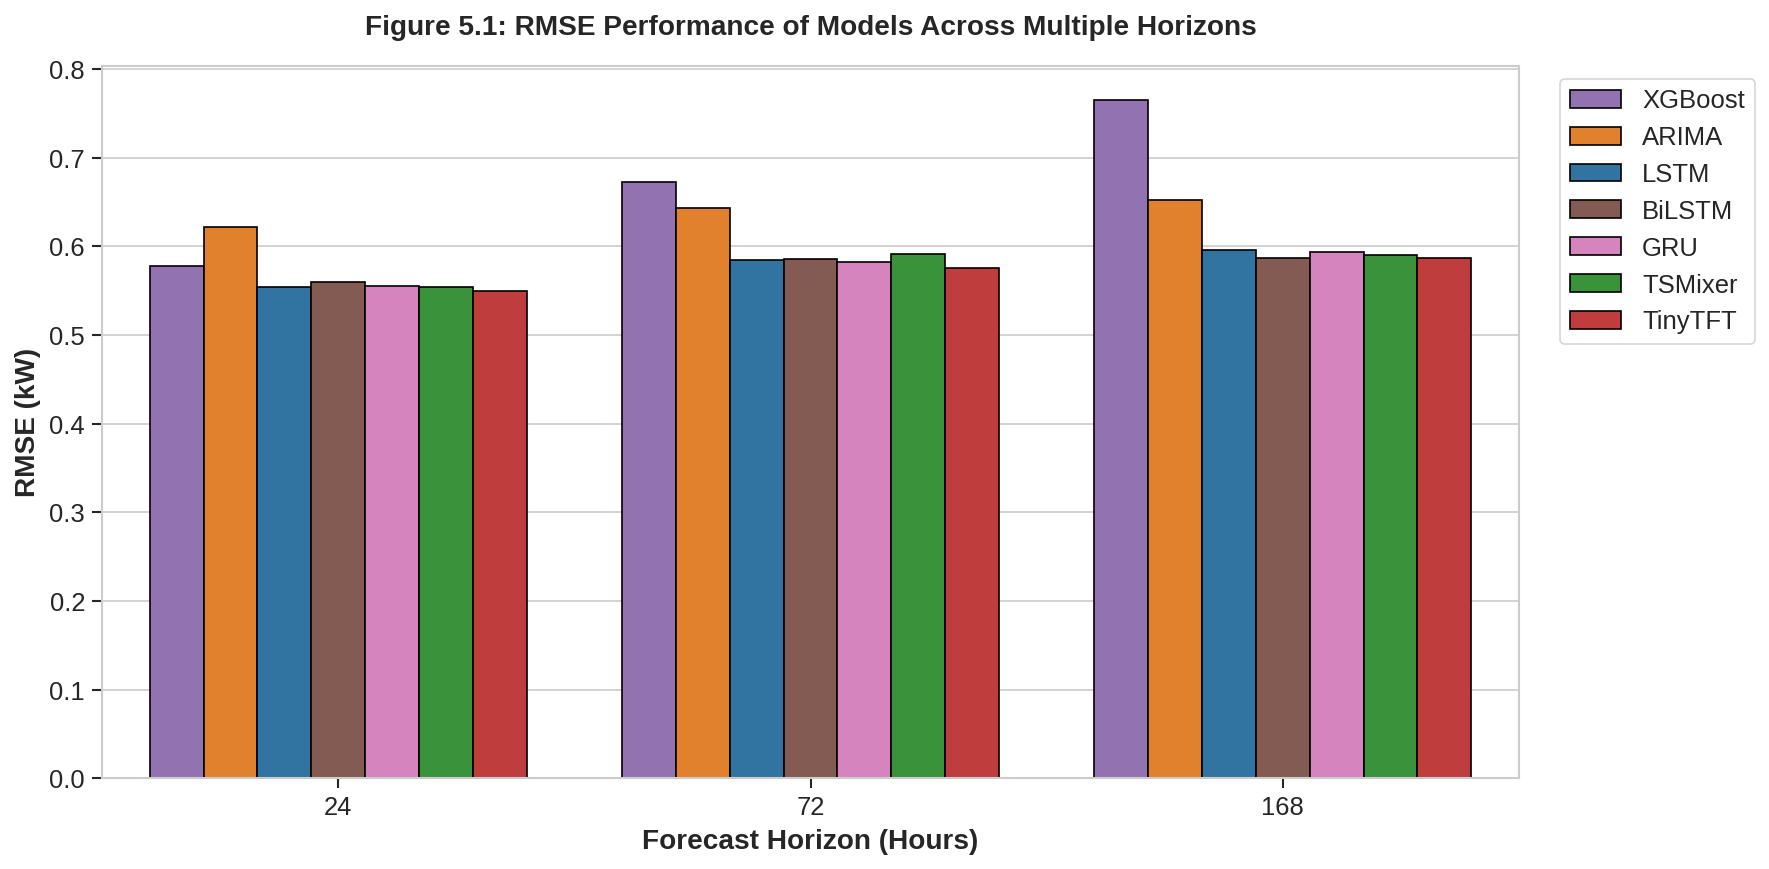

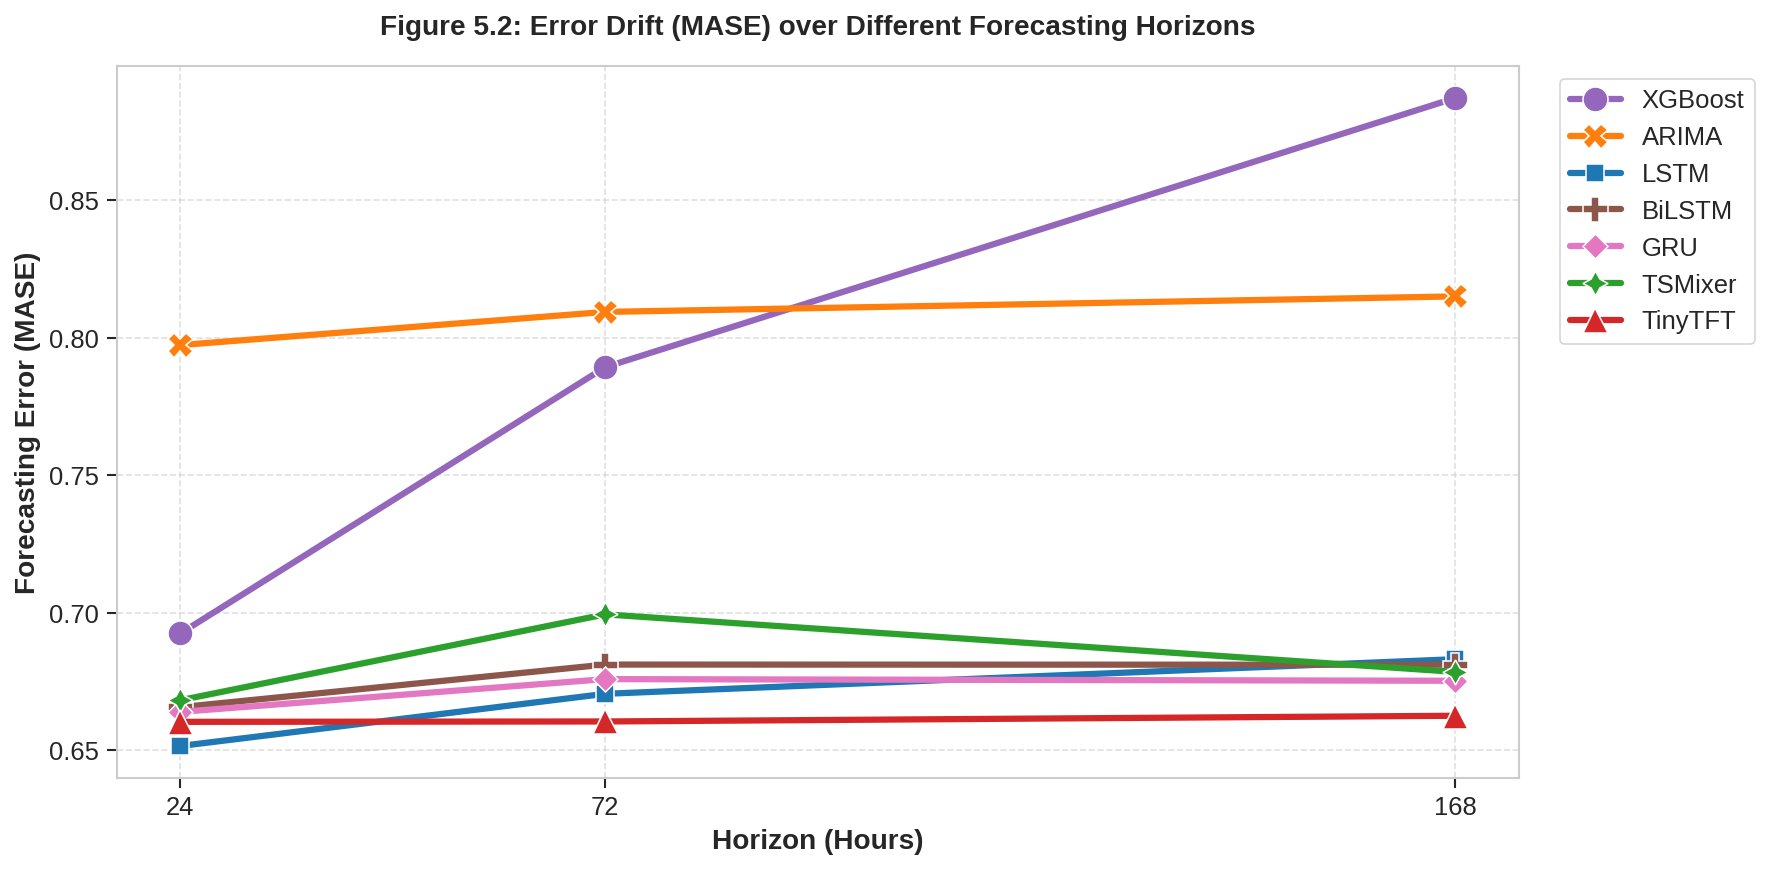

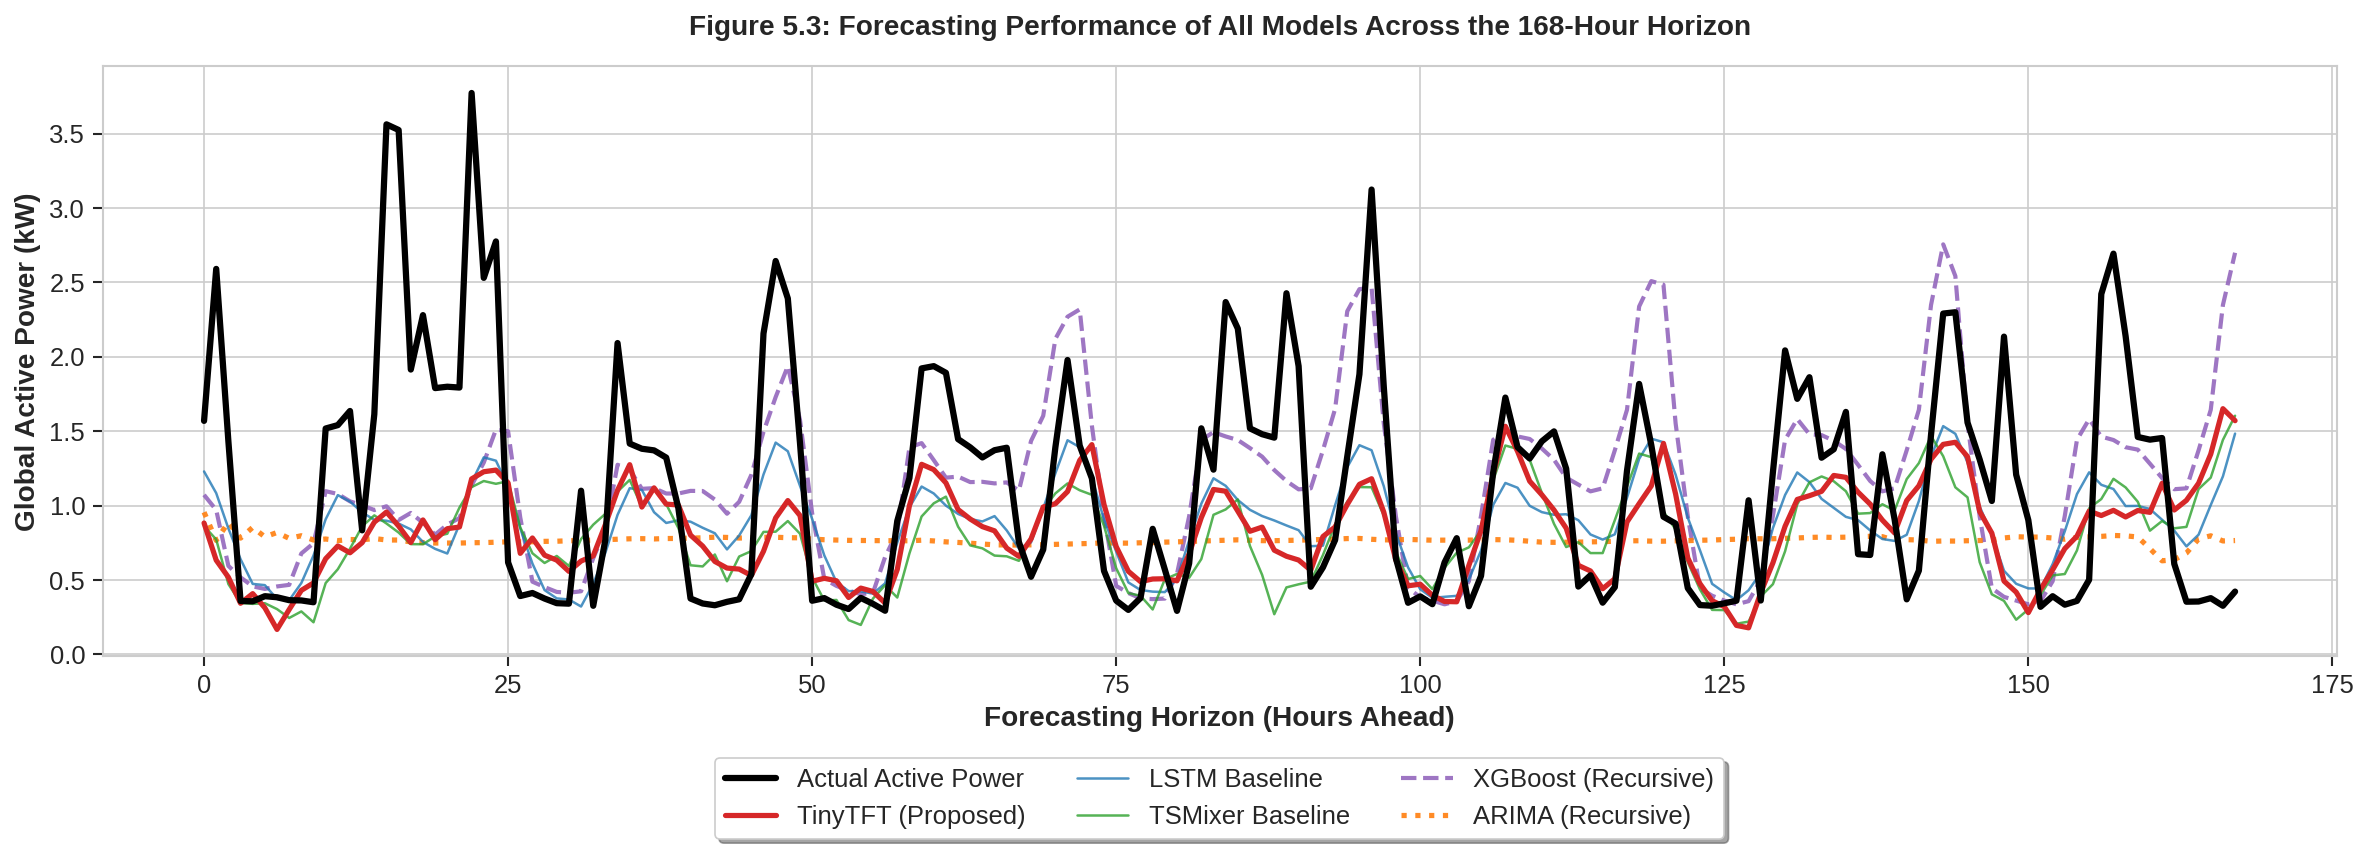

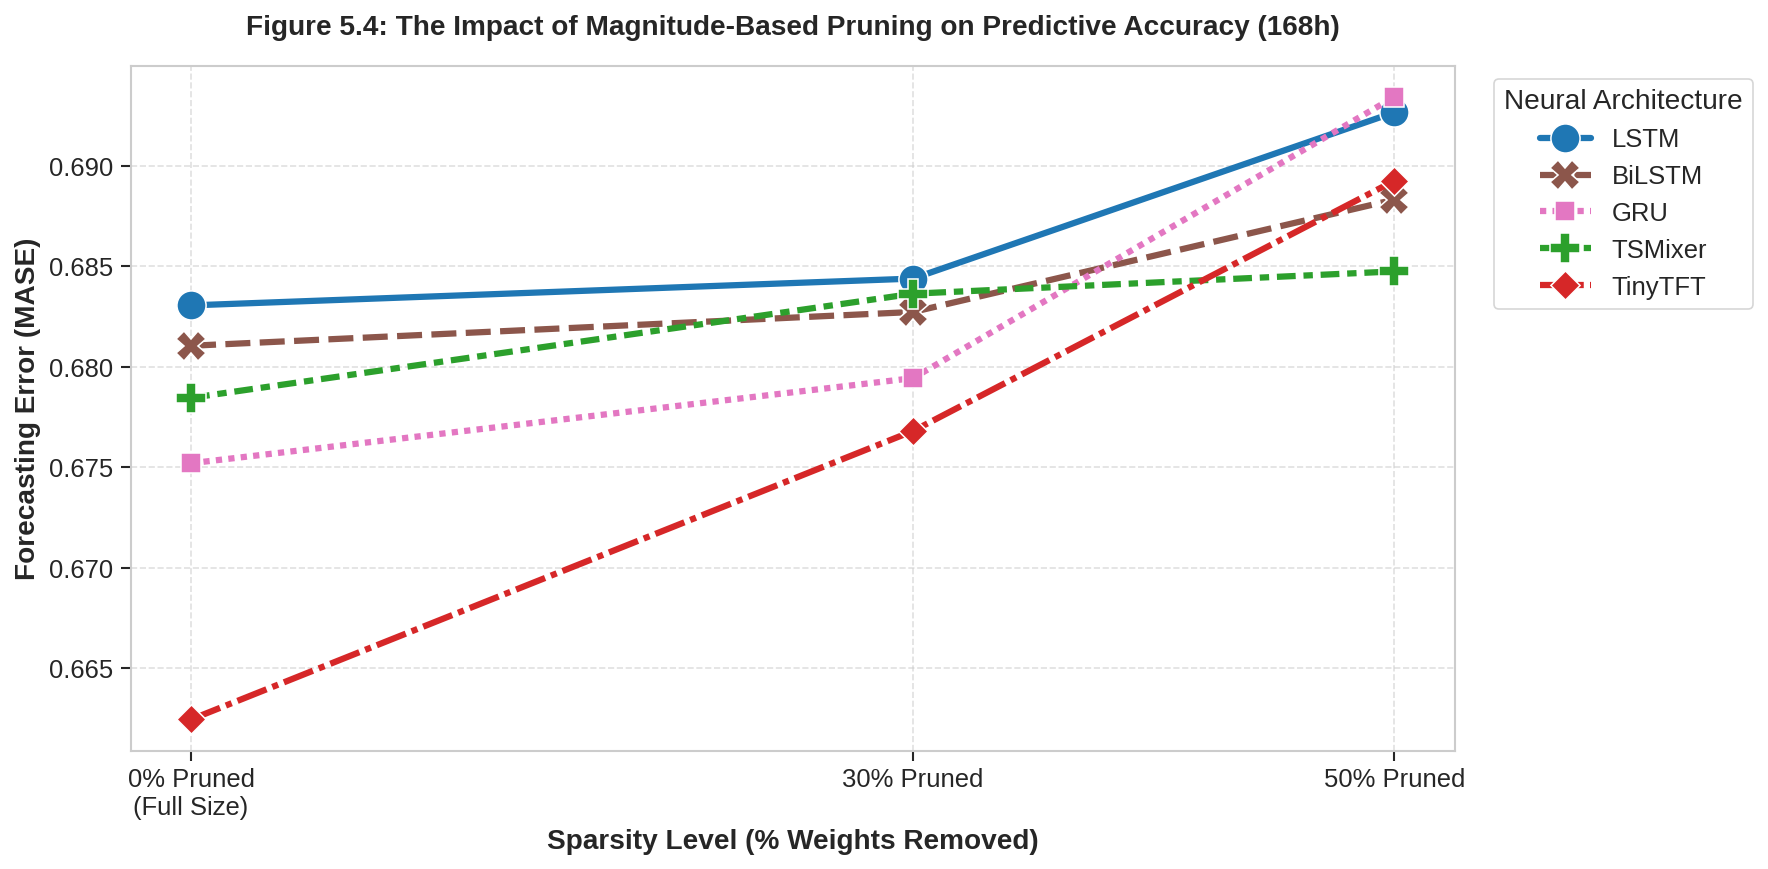

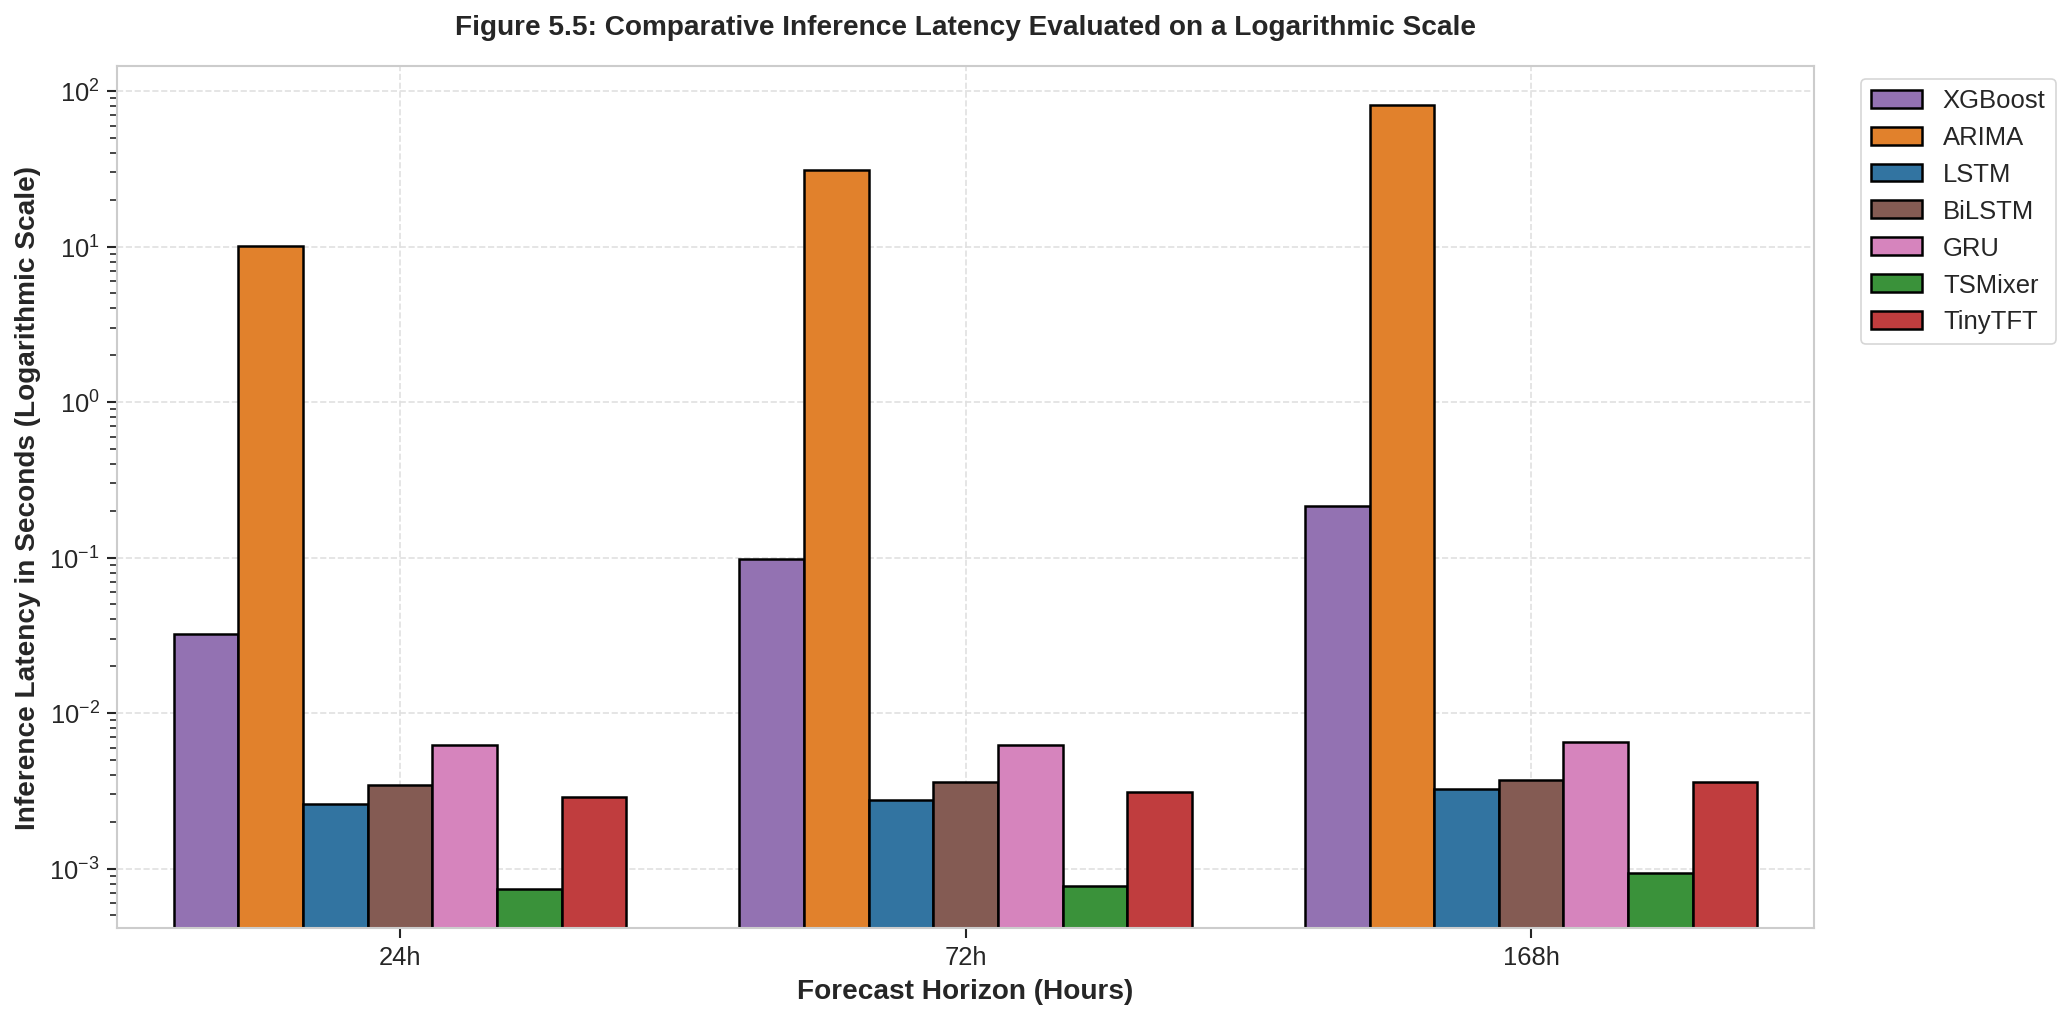

All dynamic visualizations successfully rendered.


In [29]:
# ==============================================================================
# 10. AUTOMATED DISSERTATION CHART GENERATOR
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set global academic styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.4)
custom_palette = {"TinyTFT": "#d62728", "LSTM": "#1f77b4", "TSMixer": "#2ca02c",
                  "BiLSTM": "#8c564b", "GRU": "#e377c2", "XGBoost": "#9467bd", "ARIMA": "#ff7f0e"}

print("Generating Dynamic Dissertation Figures...")

# ---------------------------------------------------------
# FIGURE 5.1: RMSE Performance Across Multiple Horizons
# ---------------------------------------------------------
plt.figure(figsize=(12, 6), dpi=150)
# Dynamic Filter: Uncompressed FP32 models and Recursive baselines only
fig51_df = results_df[
    (results_df["Configuration"].str.contains("Direct, 0% Pruned)", regex=False)) |
    (results_df["Configuration"].str.contains("Recursive", regex=False))
].copy()

sns.barplot(data=fig51_df, x="Horizon", y="RMSE", hue="Model", palette=custom_palette, edgecolor="black")
plt.title("Figure 5.1: RMSE Performance of Models Across Multiple Horizons", fontweight='bold', pad=15)
plt.ylabel("RMSE (kW)", fontweight='bold')
plt.xlabel("Forecast Horizon (Hours)", fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# FIGURE 5.2: Error Drift (MASE) over Different Horizons
# ---------------------------------------------------------
plt.figure(figsize=(12, 6), dpi=150)
# Uses the same filtered dataframe (uncompressed vs baselines)
sns.lineplot(data=fig51_df, x="Horizon", y="MASE", hue="Model", style="Model",
             markers=True, dashes=False, linewidth=3, markersize=12, palette=custom_palette)

plt.title("Figure 5.2: Error Drift (MASE) over Different Forecasting Horizons", fontweight='bold', pad=15)
plt.xticks([24, 72, 168])
plt.ylabel("Forecasting Error (MASE)", fontweight='bold')
plt.xlabel("Horizon (Hours)", fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# FIGURE 5.3: Forecasting Performance of all models (168h)
# ---------------------------------------------------------
plt.figure(figsize=(16, 6), dpi=150)

# Dynamically slice the first 168 hours of the actuals and predictions arrays
horizon_slice = 168
plt.plot(actuals_dm[:horizon_slice], label='Actual Active Power', color='black', linewidth=3, zorder=5)
plt.plot(dm_preds["TinyTFT"][:horizon_slice], label='TinyTFT (Proposed)', color=custom_palette["TinyTFT"], linewidth=2.5, zorder=4)
plt.plot(dm_preds["LSTM"][:horizon_slice], label='LSTM Baseline', color=custom_palette["LSTM"], alpha=0.8, zorder=3)
plt.plot(dm_preds["TSMixer"][:horizon_slice], label='TSMixer Baseline', color=custom_palette["TSMixer"], alpha=0.8, zorder=3)
plt.plot(dm_preds["XGBoost"][:horizon_slice], label='XGBoost (Recursive)', color=custom_palette["XGBoost"], linestyle='--', linewidth=2, alpha=0.9, zorder=2)
plt.plot(dm_preds["ARIMA"][:horizon_slice], label='ARIMA (Recursive)', color=custom_palette["ARIMA"], linestyle=':', linewidth=2.5, alpha=0.9, zorder=2)

plt.title("Figure 5.3: Forecasting Performance of All Models Across the 168-Hour Horizon", fontweight='bold', pad=15)
plt.xlabel("Forecasting Horizon (Hours Ahead)", fontweight='bold')
plt.ylabel("Global Active Power (kW)", fontweight='bold')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, shadow=True)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# FIGURE 5.4: Impact of Magnitude Pruning on Accuracy
# ---------------------------------------------------------
plt.figure(figsize=(12, 6), dpi=150)
# Dynamic Filter: Select 168h horizon, exclude INT8, exclude Recursive
fig54_df = results_df[
    (results_df["Horizon"] == 168) &
    (~results_df["Configuration"].str.contains("INT8", regex=False)) &
    (~results_df["Configuration"].str.contains("Recursive", regex=False))
].copy()

# Dynamically extract the sparsity percentage from the Configuration string
fig54_df['Sparsity'] = fig54_df['Configuration'].str.extract(r'(\d+)%').astype(int)

sns.lineplot(data=fig54_df, x="Sparsity", y="MASE", hue="Model", style="Model",
             markers=True, markersize=14, linewidth=3, palette=custom_palette)

plt.title("Figure 5.4: The Impact of Magnitude-Based Pruning on Predictive Accuracy (168h)", fontweight='bold', pad=15)
plt.xlabel("Sparsity Level (% Weights Removed)", fontweight='bold')
plt.ylabel("Forecasting Error (MASE)", fontweight='bold')
plt.xticks([0, 30, 50], labels=['0% Pruned\n(Full Size)', '30% Pruned', '50% Pruned'])
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Neural Architecture", frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# FIGURE 5.5: Comparative Inference Latency (Log Scale)
# ---------------------------------------------------------
plt.figure(figsize=(14, 7), dpi=150)
# Uses the uncompressed & recursive dataframe from Figure 5.1
ax = sns.barplot(data=fig51_df, x="Horizon", y="Latency_sec", hue="Model", palette=custom_palette, edgecolor="black", linewidth=1.2)

# Apply Log Scale for extreme latency differences (ARIMA vs TinyTFT)
ax.set_yscale("log")
ax.grid(True, which='major', linestyle='--', linewidth=0.8, color='#e0e0e0', zorder=0)
ax.set_axisbelow(True)

plt.title("Figure 5.5: Comparative Inference Latency Evaluated on a Logarithmic Scale", fontweight='bold', pad=15)
plt.ylabel("Inference Latency in Seconds (Logarithmic Scale)", fontweight='bold')
plt.xlabel("Forecast Horizon (Hours)", fontweight='bold')

# Format X-axis ticks to include "h"
ax.set_xticklabels([f"{int(x.get_text())}h" for x in ax.get_xticklabels()])

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

print("All dynamic visualizations successfully rendered.")

In [ ]:
results_df[
    (results_df["Configuration"].str.contains("Direct, 0% Pruned + INT8", regex=False)) |
    (results_df["Configuration"].str.contains("Recursive", regex=False))
]

,Model,Configuration,Horizon,Parameters,MAE,RMSE,SMAPE,MASE,Latency_sec
0,XGBoost,XGBoost (Recursive),24,0,0.457927,0.578305,48.791371,0.692439,0.032412
1,ARIMA,ARIMA (Recursive),24,5,0.527314,0.621387,56.082232,0.797360,10.128119
3,LSTM,"LSTM (Direct, 0% Pruned + INT8)",24,19736,0.430704,0.554397,45.669552,0.651275,0.009562
9,BiLSTM,"BiLSTM (Direct, 0% Pruned + INT8)",24,39448,0.440505,0.559928,46.901407,0.666095,0.016184
15,GRU,"GRU (Direct, 0% Pruned + INT8)",24,15192,0.439299,0.555711,47.074801,0.664271,0.005946
21,TSMixer,"TSMixer (Direct, 0% Pruned + INT8)",24,77028,0.441611,0.553795,48.094223,0.667767,0.001032
27,TinyTFT,"TinyTFT (Direct, 0% Pruned + INT8)",24,154648,0.436298,0.549175,47.192748,0.659734,0.003564
32,XGBoost,XGBoost (Recursive),72,0,0.521988,0.672872,52.756841,0.789307,0.097547
33,ARIMA,ARIMA (Recursive),72,5,0.535291,0.642867,57.062547,0.809423,30.950109
35,LSTM,"LSTM (Direct, 0% Pruned + INT8)",72,22856,0.443606,0.584056,47.445213,0.670784,0.009438


### 11. Deep-Dive: The Impact of INT8 Quantization on Pruned Architectures
As outlined in **Section 5.3**, to justify deployment on kilobyte-scale microcontrollers, we must prove that **Dynamic INT8 Quantization** does not destroy the learned feature representations of our pruned models.

This section isolates the **30% Pruned** neural architectures at the 168-hour horizon, comparing their native 32-bit floating-point (FP32) performance against their 8-bit integer (INT8) counterparts.

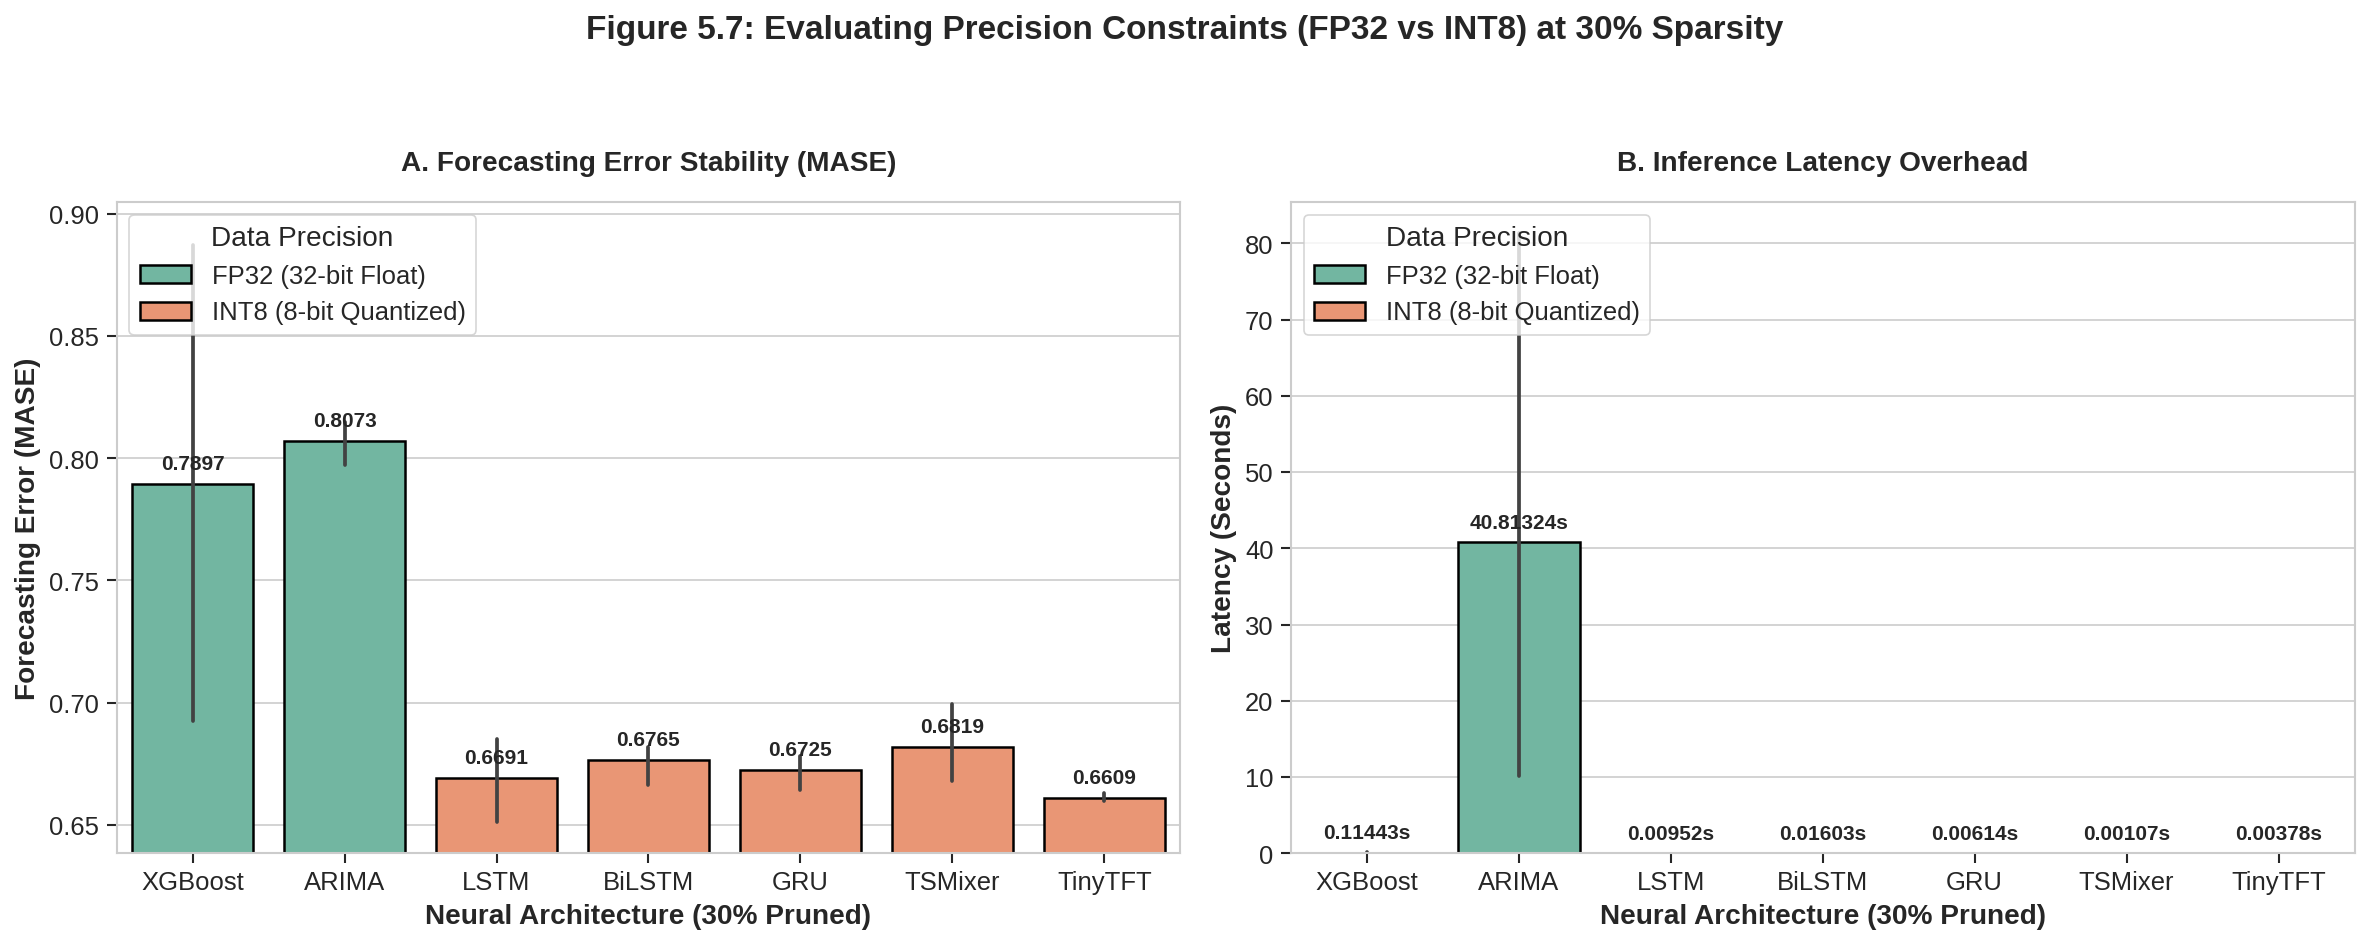

In [26]:
# ==============================================================================
# 11. 30% PRUNED vs INT8 QUANTIZATION COMPARISON
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolate the 30% Pruned models at the 168h horizon
compare_df = results_df[
    (results_df["Horizon"] == 168) &
    (results_df["Configuration"].str.contains("30% Pruned", regex=False))
].copy()

# Create a clean column to distinguish Precision (FP32 vs INT8)
compare_df['Precision'] = compare_df['Configuration'].apply(
    lambda x: 'INT8 (8-bit Quantized)' if 'INT8' in x else 'FP32 (32-bit Float)'
)

# Set up a 1x2 side-by-side subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)
sns.set_palette("Set2")

# --- Plot 1: Forecasting Error (MASE) ---
sns.barplot(data=compare_df, x="Model", y="MASE", hue="Precision",
            ax=axes[0], edgecolor="black", linewidth=1.2)

axes[0].set_title("A. Forecasting Error Stability (MASE)", fontweight='bold', pad=15)
axes[0].set_ylabel("Forecasting Error (MASE)", fontweight='bold')
axes[0].set_xlabel("Neural Architecture (30% Pruned)", fontweight='bold')

# Dynamically adjust Y-axis to highlight the microscopic differences
min_mase_compare = compare_df["MASE"].min() * 0.98
max_mase_compare = compare_df["MASE"].max() * 1.02
axes[0].set_ylim(min_mase_compare, max_mase_compare)
axes[0].legend(loc='upper left', frameon=True, title="Data Precision")

# Annotate the MASE scores directly on the bars to show they are nearly identical
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f'{height:.4f}',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=10, xytext=(0, 5),
                         textcoords='offset points', fontweight='bold')

# --- Plot 2: Inference Latency ---
sns.barplot(data=compare_df, x="Model", y="Latency_sec", hue="Precision",
            ax=axes[1], edgecolor="black", linewidth=1.2)

axes[1].set_title("B. Inference Latency Overhead", fontweight='bold', pad=15)
axes[1].set_ylabel("Latency (Seconds)", fontweight='bold')
axes[1].set_xlabel("Neural Architecture (30% Pruned)", fontweight='bold')
axes[1].legend(loc='upper left', frameon=True, title="Data Precision")

# Annotate Latency scores
for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(f'{height:.5f}s',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=10, xytext=(0, 5),
                         textcoords='offset points', fontweight='bold')

# Final Formatting
plt.suptitle("Figure 5.7: Evaluating Precision Constraints (FP32 vs INT8) at 30% Sparsity",
             fontweight='bold', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [21]:
fig51_df = results_df[
    (results_df["Configuration"].str.contains("30% Pruned + INT8", regex=False)) |
    (results_df["Configuration"].str.contains("Recursive", regex=False))
].copy()

Generating Dynamic Dissertation Figures 5.1 through 5.5...



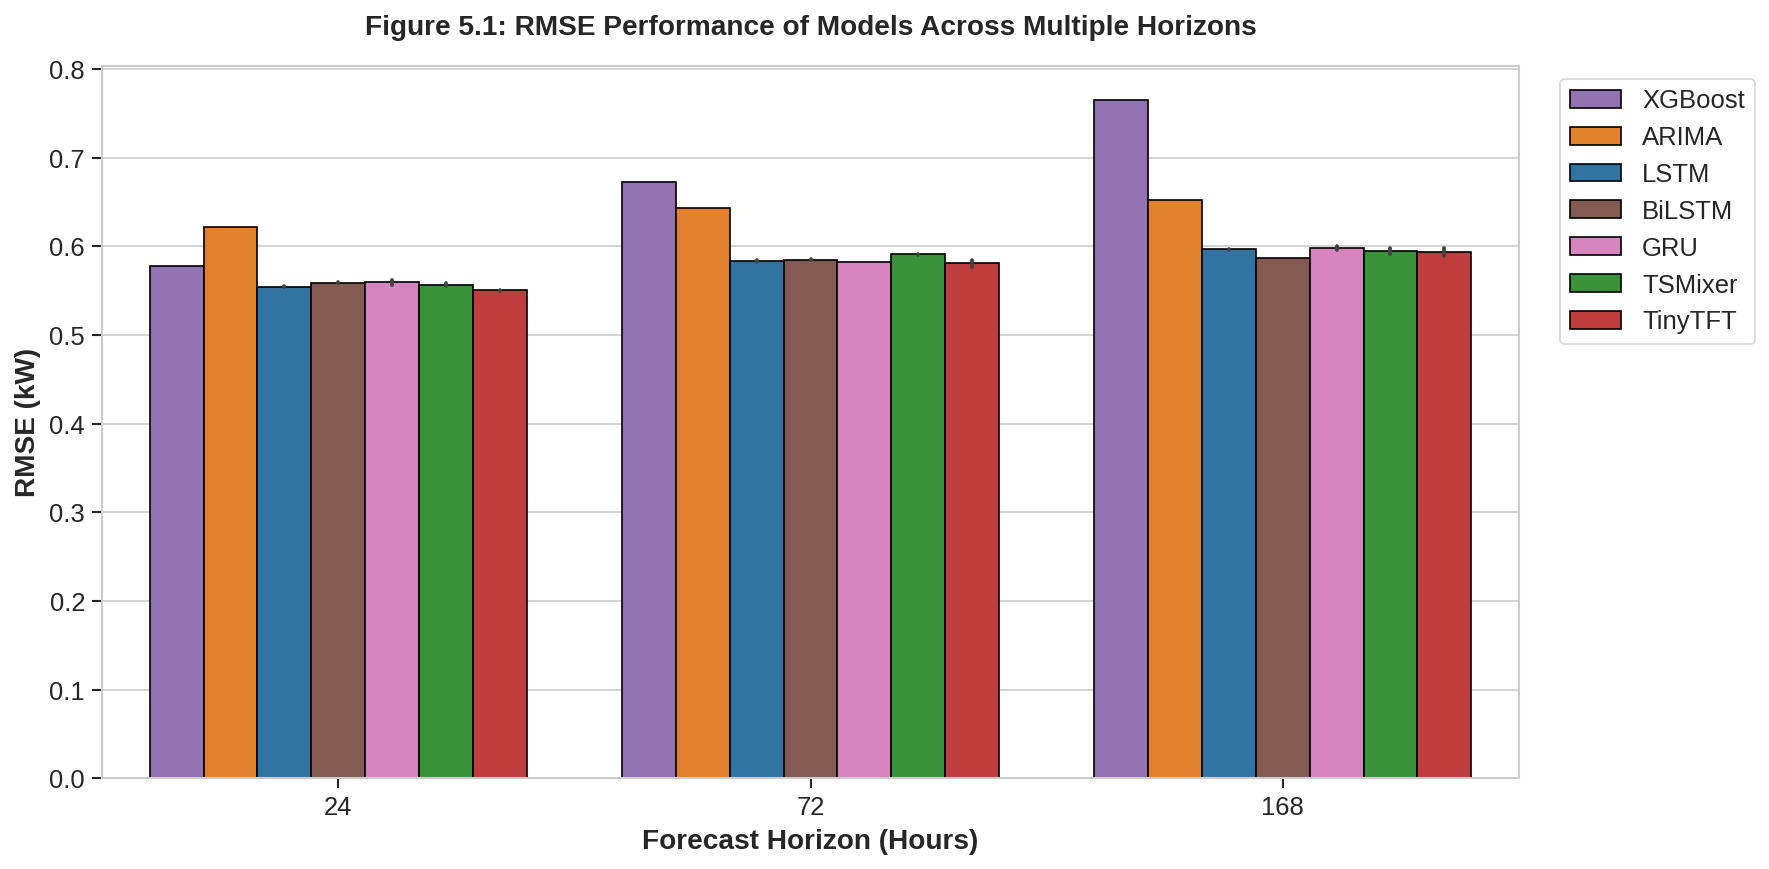

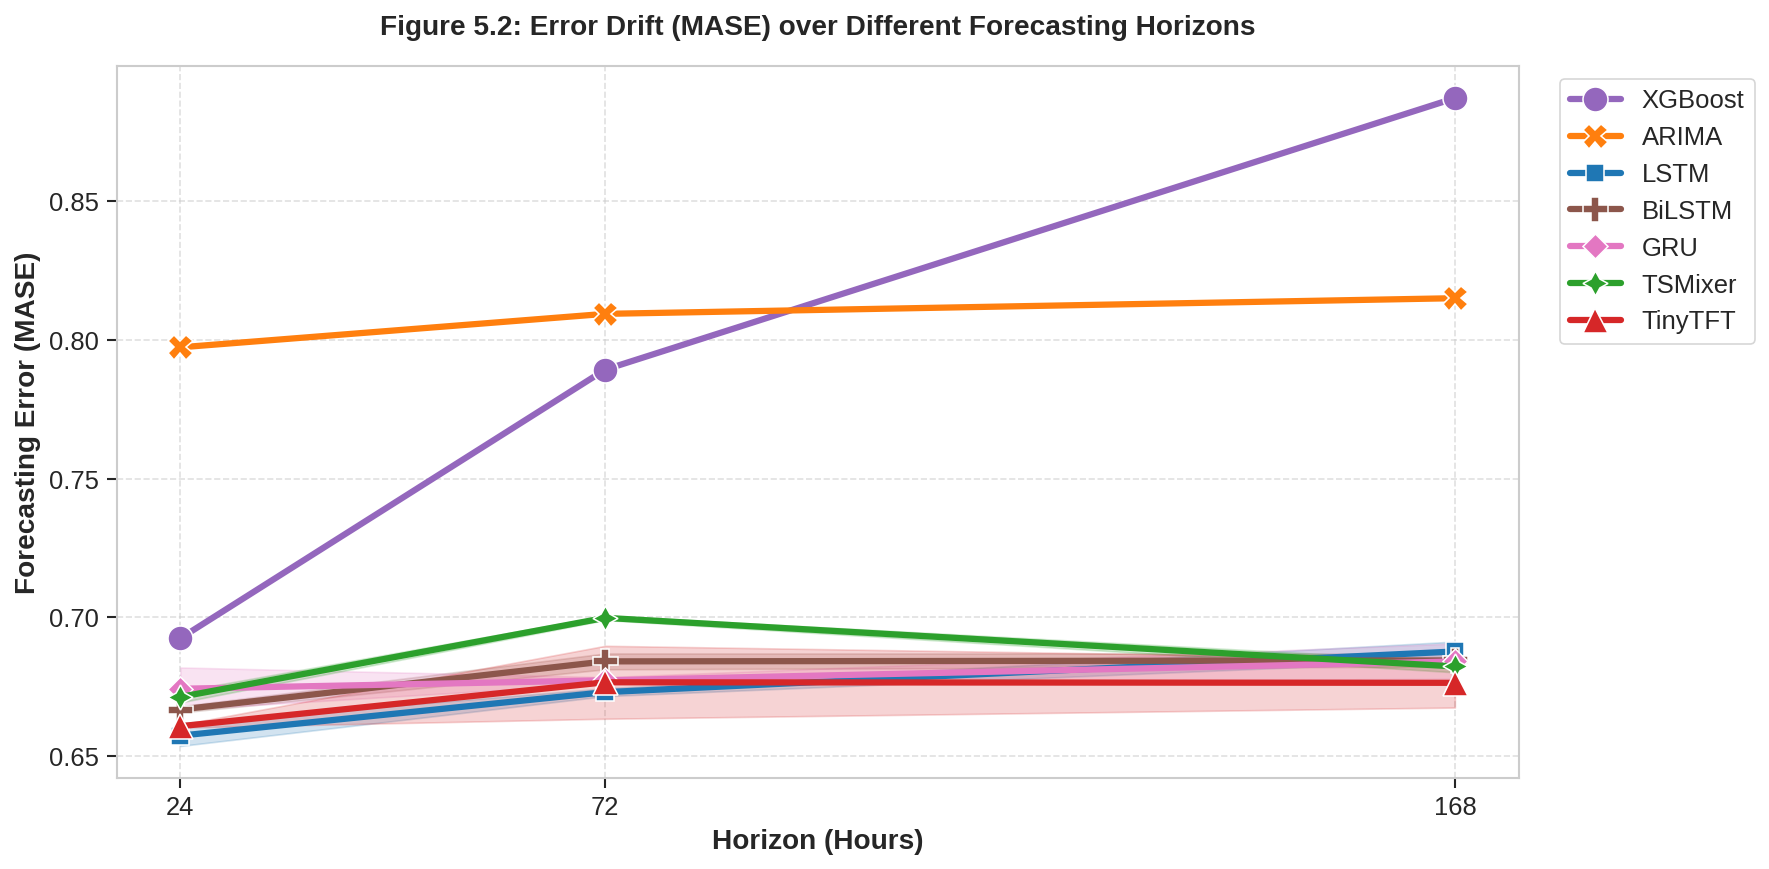

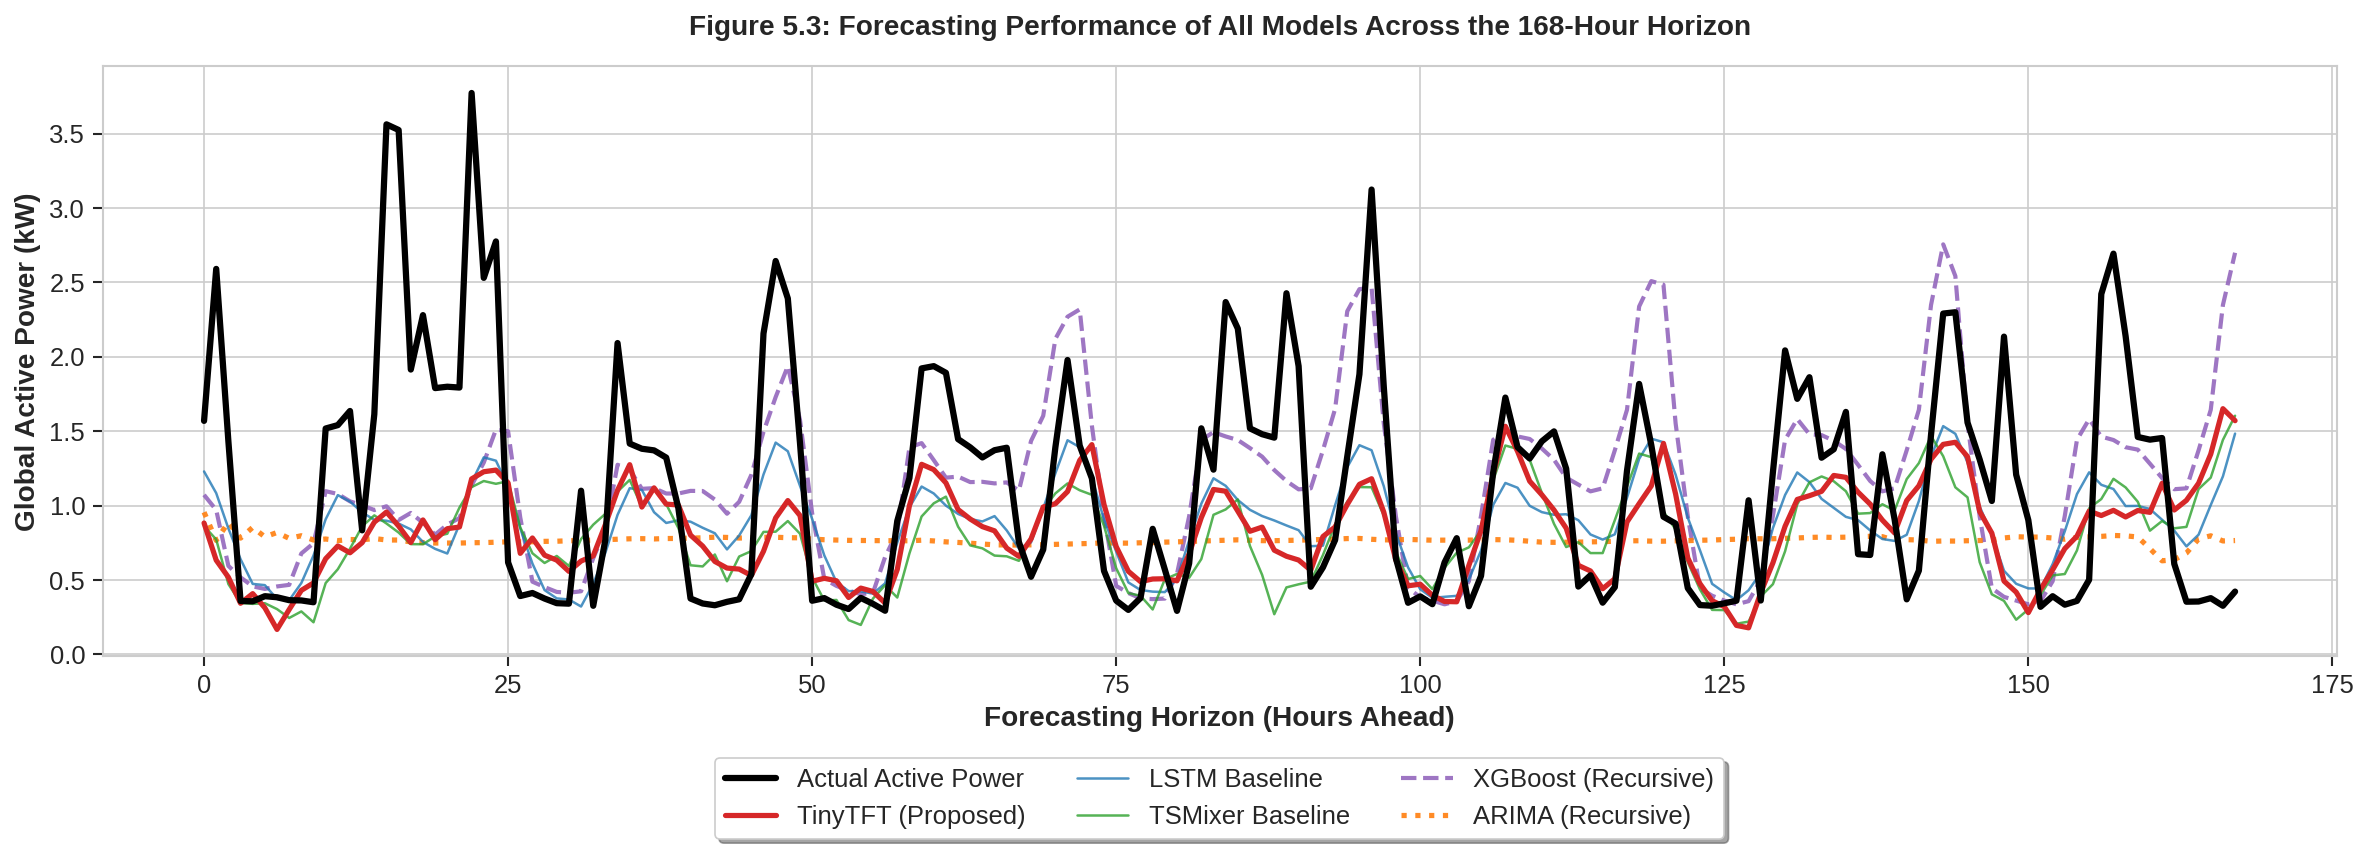

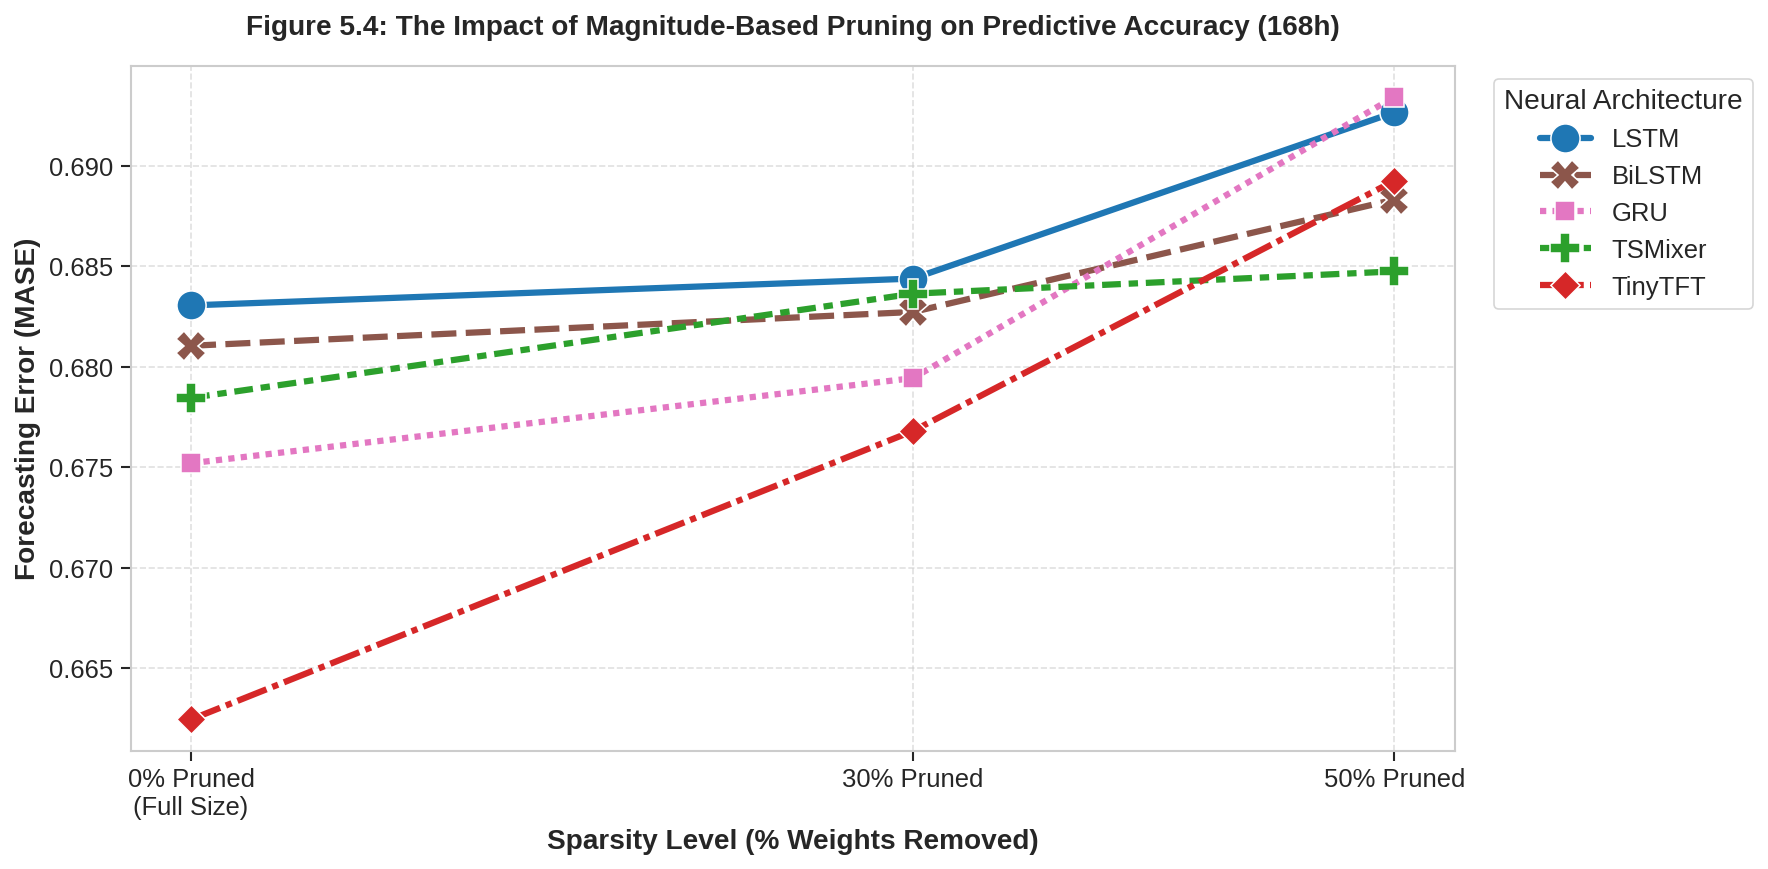

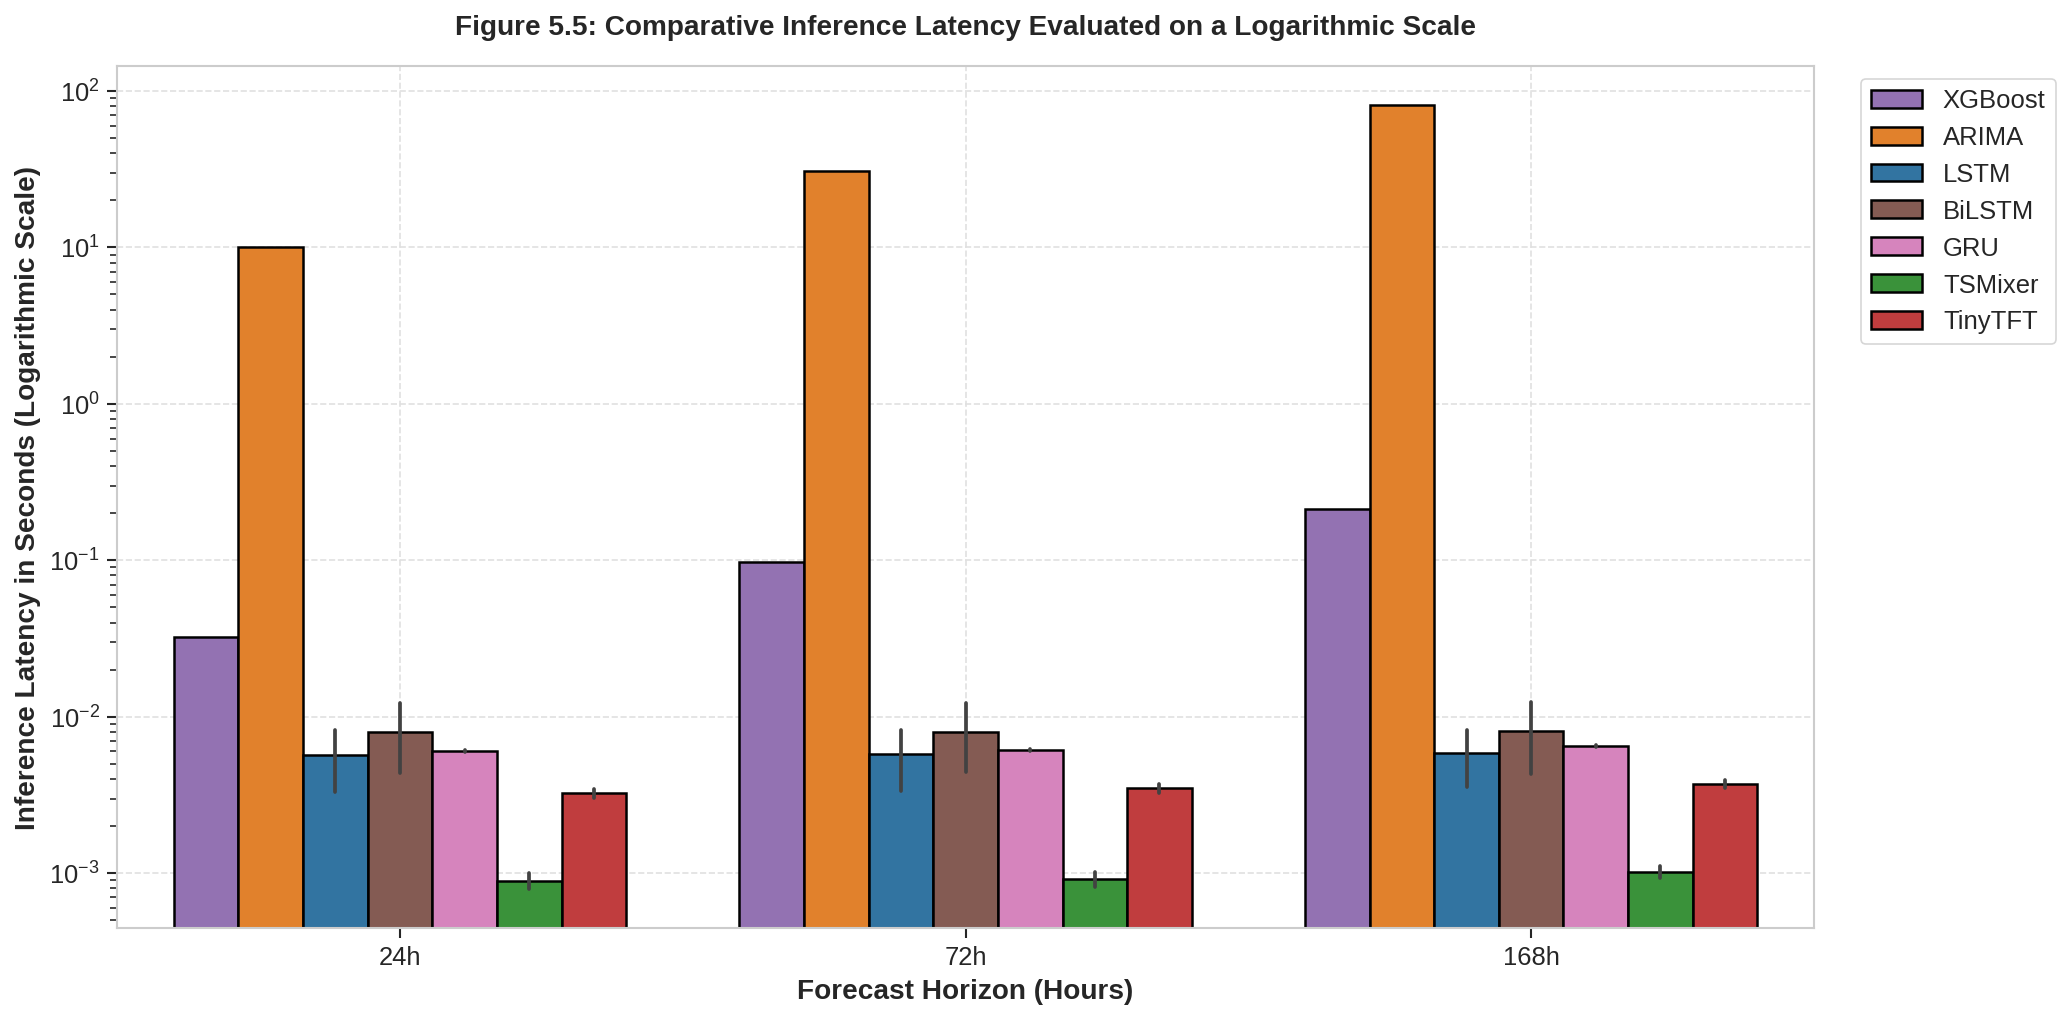

All 5 dynamic visualizations successfully rendered.


In [22]:
# ==============================================================================
# 10. AUTOMATED DISSERTATION CHART GENERATOR (ALL FIGURES)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Global Academic Styling ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.4)

# Consistent Palette mapping for all charts
custom_palette = {
    "TinyTFT": "#d62728",
    "LSTM": "#1f77b4",
    "TSMixer": "#2ca02c",
    "BiLSTM": "#8c564b",
    "GRU": "#e377c2",
    "XGBoost": "#9467bd",
    "ARIMA": "#ff7f0e"
}

print("Generating Dynamic Dissertation Figures 5.1 through 5.5...\n")

# ---------------------------------------------------------
# FIGURE 5.1: RMSE Performance Across Multiple Horizons
# ---------------------------------------------------------
plt.figure(figsize=(12, 6), dpi=150)
fig51_df = results_df[
    (results_df["Configuration"].str.contains("0% Pruned", regex=False)) |
    (results_df["Configuration"].str.contains("Recursive", regex=False))
].copy()

sns.barplot(data=fig51_df, x="Horizon", y="RMSE", hue="Model", palette=custom_palette, edgecolor="black")
plt.title("Figure 5.1: RMSE Performance of Models Across Multiple Horizons", fontweight='bold', pad=15)
plt.ylabel("RMSE (kW)", fontweight='bold')
plt.xlabel("Forecast Horizon (Hours)", fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# FIGURE 5.2: Error Drift (MASE) over Different Horizons
# ---------------------------------------------------------
plt.figure(figsize=(12, 6), dpi=150)
sns.lineplot(data=fig51_df, x="Horizon", y="MASE", hue="Model", style="Model",
             markers=True, dashes=False, linewidth=3, markersize=12, palette=custom_palette)

plt.title("Figure 5.2: Error Drift (MASE) over Different Forecasting Horizons", fontweight='bold', pad=15)
plt.xticks([24, 72, 168])
plt.ylabel("Forecasting Error (MASE)", fontweight='bold')
plt.xlabel("Horizon (Hours)", fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# FIGURE 5.3: Forecasting Performance of all models (168h)
# ---------------------------------------------------------
plt.figure(figsize=(16, 6), dpi=150)
horizon_slice = 168
plt.plot(actuals_dm[:horizon_slice], label='Actual Active Power', color='black', linewidth=3, zorder=5)
plt.plot(dm_preds["TinyTFT"][:horizon_slice], label='TinyTFT (Proposed)', color=custom_palette["TinyTFT"], linewidth=2.5, zorder=4)
plt.plot(dm_preds["LSTM"][:horizon_slice], label='LSTM Baseline', color=custom_palette["LSTM"], alpha=0.8, zorder=3)
plt.plot(dm_preds["TSMixer"][:horizon_slice], label='TSMixer Baseline', color=custom_palette["TSMixer"], alpha=0.8, zorder=3)
plt.plot(dm_preds["XGBoost"][:horizon_slice], label='XGBoost (Recursive)', color=custom_palette["XGBoost"], linestyle='--', linewidth=2, alpha=0.9, zorder=2)
plt.plot(dm_preds["ARIMA"][:horizon_slice], label='ARIMA (Recursive)', color=custom_palette["ARIMA"], linestyle=':', linewidth=2.5, alpha=0.9, zorder=2)

plt.title("Figure 5.3: Forecasting Performance of All Models Across the 168-Hour Horizon", fontweight='bold', pad=15)
plt.xlabel("Forecasting Horizon (Hours Ahead)", fontweight='bold')
plt.ylabel("Global Active Power (kW)", fontweight='bold')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, shadow=True)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# FIGURE 5.4: Impact of Magnitude Pruning on Accuracy
# ---------------------------------------------------------
plt.figure(figsize=(12, 6), dpi=150)
fig54_df = results_df[
    (results_df["Horizon"] == 168) &
    (~results_df["Configuration"].str.contains("INT8", regex=False)) &
    (~results_df["Configuration"].str.contains("Recursive", regex=False))
].copy()

fig54_df['Sparsity'] = fig54_df['Configuration'].str.extract(r'(\d+)%').astype(int)

sns.lineplot(data=fig54_df, x="Sparsity", y="MASE", hue="Model", style="Model",
             markers=True, markersize=14, linewidth=3, palette=custom_palette)

plt.title("Figure 5.4: The Impact of Magnitude-Based Pruning on Predictive Accuracy (168h)", fontweight='bold', pad=15)
plt.xlabel("Sparsity Level (% Weights Removed)", fontweight='bold')
plt.ylabel("Forecasting Error (MASE)", fontweight='bold')
plt.xticks([0, 30, 50], labels=['0% Pruned\n(Full Size)', '30% Pruned', '50% Pruned'])
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Neural Architecture", frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# FIGURE 5.5: Comparative Inference Latency (Log Scale)
# ---------------------------------------------------------
plt.figure(figsize=(14, 7), dpi=150)
ax = sns.barplot(data=fig51_df, x="Horizon", y="Latency_sec", hue="Model",
                 palette=custom_palette, edgecolor="black", linewidth=1.2)

ax.set_yscale("log")
ax.grid(True, which='major', linestyle='--', linewidth=0.8, color='#e0e0e0', zorder=0)
ax.set_axisbelow(True)

plt.title("Figure 5.5: Comparative Inference Latency Evaluated on a Logarithmic Scale", fontweight='bold', pad=15)
plt.ylabel("Inference Latency in Seconds (Logarithmic Scale)", fontweight='bold')
plt.xlabel("Forecast Horizon (Hours)", fontweight='bold')
ax.set_xticklabels([f"{int(x.get_text())}h" for x in ax.get_xticklabels()])

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

print("All 5 dynamic visualizations successfully rendered.")